Imports and Initialization

In [ ]:
import os
os.environ['PYTHONHASHSEED'] = '0'

In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import roc_auc_score, classification_report,confusion_matrix, ConfusionMatrixDisplay
from sklearn.ensemble import RandomForestClassifier
from sklearn.decomposition import PCA, KernelPCA
from sklearn.model_selection import GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.svm import SVC
from sklearn.naive_bayes import MultinomialNB
from sklearn.utils import shuffle
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.decomposition import NMF

import random

random.seed(0)
np.random.seed(0)

In [ ]:
import tensorflow as tf
tf.random.set_seed(0)
print(tf.config.list_physical_devices())

[PhysicalDevice(name='/physical_device:CPU:0', device_type='CPU')]


In [ ]:
from google.colab import userdata
login(token=userdata.get('HF_TOKEN'))

In [ ]:
from transformers import AutoTokenizer, AutoModel, AutoModelForSequenceClassification, Trainer, TrainingArguments
import torch
from torch.utils.data import Dataset

Data Imports

In [ ]:
import kagglehub
path = kagglehub.dataset_download("novandraanugrah/bitcoin-historical-datasets-2018-2024")
df = pd.read_csv(path+'/btc_1h_data_2018_to_2025.csv')

100%|██████████| 19.5M/19.5M [00:00<00:00, 123MB/s]

Extracting files...


In [ ]:
df.head(5)

,Open time,Open,High,Low,Close,Volume,Close time,Quote asset volume,Number of trades,Taker buy base asset volume,Taker buy quote asset volume,Ignore
0,2018-01-01 00:00:00.000000,13715.65,13715.65,13400.01,13529.01,443.356199,2018-01-01 00:59:59.999000,5.993910e+06,5228,228.521921,3.090541e+06,0
1,2018-01-01 01:00:00.000000,13528.99,13595.89,13155.38,13203.06,383.697006,2018-01-01 01:59:59.999000,5.154522e+06,4534,180.840403,2.430449e+06,0
2,2018-01-01 02:00:00.000000,13203.00,13418.43,13200.00,13330.18,429.064572,2018-01-01 02:59:59.999000,5.710192e+06,4887,192.237935,2.558505e+06,0
3,2018-01-01 03:00:00.000000,13330.26,13611.27,13290.00,13410.03,420.087030,2018-01-01 03:59:59.999000,5.657448e+06,4789,137.918407,1.858041e+06,0
4,2018-01-01 04:00:00.000000,13434.98,13623.29,13322.15,13601.01,340.807329,2018-01-01 04:59:59.999000,4.588047e+06,4563,172.957635,2.328058e+06,0


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 71783 entries, 0 to 71782
Data columns (total 12 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Open time                     71782 non-null  object 
 1   Open                          71783 non-null  float64
 2   High                          71783 non-null  float64
 3   Low                           71783 non-null  float64
 4   Close                         71783 non-null  float64
 5   Volume                        71783 non-null  float64
 6   Close time                    71782 non-null  object 
 7   Quote asset volume            71783 non-null  float64
 8   Number of trades              71783 non-null  int64  
 9   Taker buy base asset volume   71783 non-null  float64
 10  Taker buy quote asset volume  71783 non-null  float64
 11  Ignore                        71783 non-null  int64  
dtypes: float64(8), int64(2), object(2)
memory usage: 6.6+ MB


In [ ]:
df.isnull().sum()

,0
Open time,1
Open,0
High,0
Low,0
Close,0
Volume,0
Close time,1
Quote asset volume,0
Number of trades,0
Taker buy base asset volume,0


In [ ]:
df = df.dropna(subset=['Open time', 'Close time'])

In [ ]:
df[df.duplicated()]

,Open time,Open,High,Low,Close,Volume,Close time,Quote asset volume,Number of trades,Taker buy base asset volume,Taker buy quote asset volume,Ignore


Quick Feature Engineering

In [ ]:
df['Open time'] = pd.to_datetime(df['Open time'], errors='coerce')
df['Close time'] = pd.to_datetime(df['Close time'], errors='coerce')
df['year_open'] = df['Open time'].dt.year
df['month_open'] = df['Open time'].dt.month

df.drop('Ignore', axis=1, inplace=True)

In [ ]:
(df.drop({'Open time','Close time'} ,axis=1)).describe()

,Open,High,Low,Close,Volume,Quote asset volume,Number of trades,Taker buy base asset volume,Taker buy quote asset volume,year_open,month_open
count,71782.000000,71782.000000,71782.000000,71782.000000,71782.000000,7.178200e+04,7.178200e+04,71782.000000,7.178200e+04,71782.000000,71782.000000
mean,38291.300859,38445.200622,38129.748494,38292.119990,2678.948101,7.694386e+07,8.504361e+04,1330.087225,3.797401e+07,2021.615893,6.407748
std,32492.452241,32591.765764,32389.658650,32492.582492,3939.603615,1.039173e+08,1.136325e+05,1962.059546,5.174691e+07,2.366885,3.486415
min,3172.620000,3184.750000,3156.260000,3172.050000,0.000000,0.000000e+00,0.000000e+00,0.000000,0.000000e+00,2018.000000,1.000000
25%,9563.222500,9603.000000,9514.737500,9563.477500,821.443882,1.594293e+07,1.895125e+04,405.390795,7.760619e+06,2020.000000,3.000000
50%,28193.615000,28304.125000,28077.645000,28194.110000,1459.700266,4.277873e+07,4.435350e+04,730.255866,2.068234e+07,2022.000000,6.000000
75%,59538.745000,59800.000000,59299.335000,59541.835000,2814.851193,9.779801e+07,1.014800e+05,1397.981473,4.815698e+07,2024.000000,9.000000
max,126011.180000,126199.630000,125252.740000,126011.180000,137207.188600,3.005634e+09,3.520247e+06,68611.450390,1.502977e+09,2026.000000,12.000000


Quick Feature Engineering:

-> Features explained to me by Claude (thanks!)
* Open, High, Low, Close — four snapshots of price within the hour. Open is where it started, High and Low are the extremes each side pushed to, Close is where it ended. The relationship between these four tells you who won.
* Volume — total BTC that changed hands. This is important because price moves with volume mean something; price moves without volume are suspect. A 5% drop on low volume is probably noise. A 5% drop on 3× average volume is a regime change.
* Quote asset volume — same as Volume but in dollars. Volume says "100 BTC traded." Quote asset volume says "those 100 BTC were worth $6.2 million." More economically meaningful for comparisons across time (100 BTC in 2018 ≠ 100 BTC in 2021 in dollar terms).
* Number of trades — how many separate transactions made up that volume. 1000 small retail trades vs 1 whale trade moving the same total volume are very different situations. High trades + moderate volume = retail activity. Low trades + high volume = institutional.
* Taker buy base asset volume — every trade in a market has two sides: the maker placed a limit order and waited patiently, the taker placed a market order and hit that limit. Takers are the impatient side — they wanted to transact now regardless of price. Taker buy volume specifically means: buyers who were aggressive enough to cross the spread. High taker buy volume = buying pressure, people urgently want in. The complement (taker sell volume) = selling pressure, people urgently want out.
* Taker buy quote asset volume — same thing, denominated in dollars.

-> Features to Engineer:
* Log returns - price has no natural scale and drifts over time — it's non-stationary. Your model can't generalise from "price was 8000" to "price is 60000." But returns are roughly stationary: a 2% move means the same thing whether BTC is at 8k or 60k. Log specifically because log returns are additive over time (daily return = sum of hourly log returns), and because they're symmetric (a 10% up followed by a 10% down in log space gets you back to zero, unlike arithmetic returns).
* Realised volatility - Volatility is how much the price is moving, regardless of direction. A 24-hour rolling standard deviation of log returns gives you a local estimate of how turbulent the market is right now. You'd compute this at multiple windows (24h, 168h) because volatility has structure at different timescales — short-term spikes vs regime-level elevated vol.
* Candle structure features - These extract information from the relationship between O, H, L, C. The signed return within the candle. Positive = bullish candle (closed higher than opened), negative = bearish. The magnitude tells you how decisive the move was. A small body = indecision.
* Upper Wick - How far price pushed above the candle body before being rejected. A long upper wick means buyers tried to push higher but sellers beat them back. In trading this is called a rejection — bearish signal.
* Lower Wick - Symmetric: how far price pushed below the body before recovering. Long lower wick = sellers tried to push lower, buyers absorbed it. Bullish signal.
* High-Low Range - Total price range of the candle, normalised. This is a within-candle volatility measure — how wide was the swing this hour, regardless of direction.
* Volume signals -
1. Taker ratio: The fraction of volume that was aggressive buying. Ranges 0–1. Above 0.5 means more aggressive buyers than sellers — net buying pressure. This is one of the more genuinely predictive microstructure signals.
2. Volume MA ratio: Is this hour's volume unusually high or low relative to recent history? A ratio of 2.0 means twice the normal volume — something is happening. Normalising this way makes it comparable across different periods (volume in 2021 bull run was structurally higher than 2018 bear).
* RSI (Relative Strength Index):
Bounded between 0 and 100. Measures whether recent moves have been predominantly up or down. Above 70 = overbought (price has been rising a lot, potential reversal). Below 30 = oversold. The 14-period window is the standard convention. Mechanically it's the ratio of average gains to average losses over the window.
* MACD (Moving Average Convergence Divergence):
The difference between a 12-period and 26-period exponential moving average of price. When the short EMA is above the long EMA, momentum is upward (MACD positive). The signal line is a 9-period EMA of the MACD itself. The histogram is MACD minus signal — it's the rate of change of momentum. Crossovers of MACD through the signal line are classic entry/exit signals in technical analysis.
* Bollinger Band position: Where is price relative to its recent range, measured in standard deviations. Zero = exactly at the 20-period mean. +1 = at the upper band, historically the top of the "normal" range. -1 = lower band. This is essentially a z-score of price relative to recent history — it tells you whether price is stretched. Unlike RSI it's not bounded, so extreme values (±2, ±3) are genuinely unusual.

Summary:

* Log returns - Direction and magnitude of price change
* Realised vol - How turbulent the market is right now
* Candle structure - Who won the hour — buyers or sellers, and by how much
* Volume signals - Conviction and aggression behind the move
* RSI - Whether the trend is exhausted
* MACD - Trend direction and momentum
* BB position - Whether price is stretched relative to recent range

In [ ]:
# Returns and Volume
df['log_return'] = np.log(df['Close'] / df['Close'].shift(1))
df['realised_vol_24h'] = df['log_return'].rolling(24).std()
df['realised_vol_168h'] = df['log_return'].rolling(168).std()  # 1 week

In [ ]:
# Candle structure (price action)
df['candle_body'] = (df['Close'] - df['Open']) / df['Open']   # signed return within candle
df['upper_wick'] = (df['High'] - df[['Open','Close']].max(axis=1)) / df['Open']
df['lower_wick'] = (df[['Open','Close']].min(axis=1) - df['Low']) / df['Open']
df['hl_range'] = (df['High'] - df['Low']) / df['Open']        # volatility within candle

In [ ]:
# Volume Signals
df['taker_ratio'] = df['Taker buy base asset volume'] / df['Volume']  # buy pressure
df['volume_ma_ratio'] = df['Volume'] / df['Volume'].rolling(24).mean()  # volume spike

In [ ]:
# Momentum
# RSI — measures overbought/oversold, bounded 0-100
delta = df['Close'].diff()
gain = delta.clip(lower=0).rolling(14).mean()
loss = -delta.clip(upper=0).rolling(14).mean()
df['rsi'] = 100 - (100 / (1 + gain / loss))

# MACD — trend following
ema12 = df['Close'].ewm(span=12).mean()
ema26 = df['Close'].ewm(span=26).mean()
df['macd'] = ema12 - ema26
df['macd_signal'] = df['macd'].ewm(span=9).mean()
df['macd_hist'] = df['macd'] - df['macd_signal']

# BB Position
ma20 = df['Close'].rolling(20).mean()
std20 = df['Close'].rolling(20).std()
df['bb_position'] = (df['Close'] - ma20) / (2 * std20)  # -1 to +1 roughly

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 71782 entries, 0 to 71781
Data columns (total 27 columns):
 #   Column                        Non-Null Count  Dtype         
---  ------                        --------------  -----         
 0   Open time                     71782 non-null  datetime64[ns]
 1   Open                          71782 non-null  float64       
 2   High                          71782 non-null  float64       
 3   Low                           71782 non-null  float64       
 4   Close                         71782 non-null  float64       
 5   Volume                        71782 non-null  float64       
 6   Close time                    71782 non-null  datetime64[ns]
 7   Quote asset volume            71782 non-null  float64       
 8   Number of trades              71782 non-null  int64         
 9   Taker buy base asset volume   71782 non-null  float64       
 10  Taker buy quote asset volume  71782 non-null  float64       
 11  year_open                     717

Quick EDA

In [ ]:
A = df.drop({'Open', 'High', 'Low', 'Close', 'Volume', 'Quote asset volume', 'Taker buy quote asset volume', 'year_open', 'month_open'},axis=1)

In [ ]:
A.info()

<class 'pandas.core.frame.DataFrame'>
Index: 71782 entries, 0 to 71781
Data columns (total 18 columns):
 #   Column                       Non-Null Count  Dtype         
---  ------                       --------------  -----         
 0   Open time                    71782 non-null  datetime64[ns]
 1   Close time                   71782 non-null  datetime64[ns]
 2   Number of trades             71782 non-null  int64         
 3   Taker buy base asset volume  71782 non-null  float64       
 4   log_return                   71781 non-null  float64       
 5   realised_vol_24h             71758 non-null  float64       
 6   realised_vol_168h            71614 non-null  float64       
 7   candle_body                  71782 non-null  float64       
 8   upper_wick                   71782 non-null  float64       
 9   lower_wick                   71782 non-null  float64       
 10  hl_range                     71782 non-null  float64       
 11  taker_ratio                  71779 non-null  f

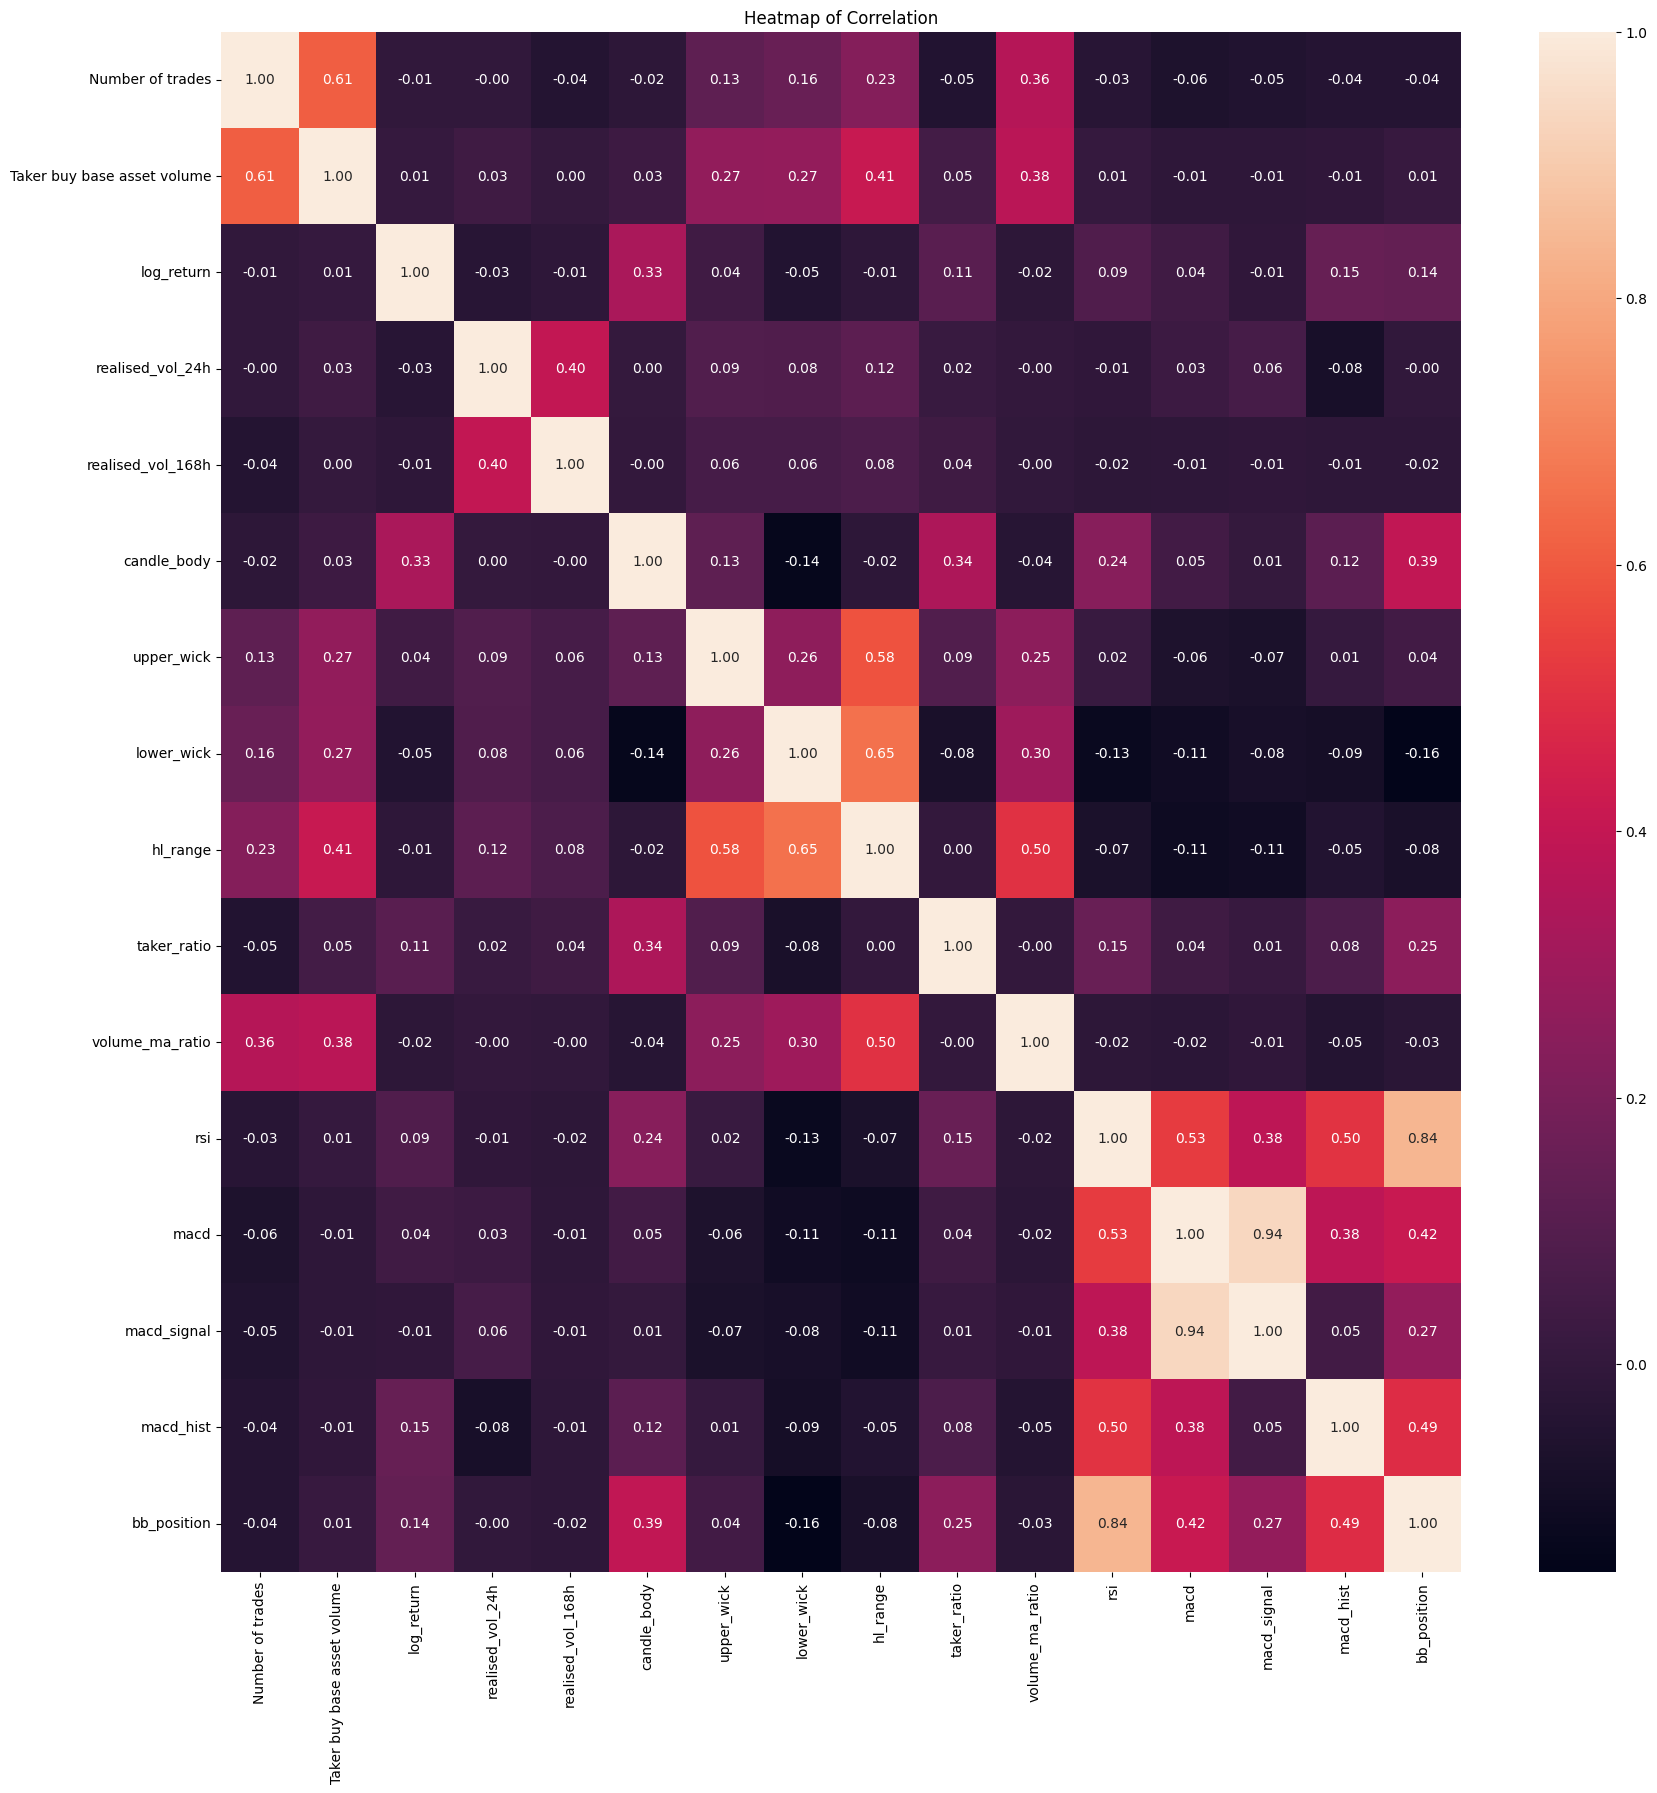

In [ ]:
plt.figure(figsize=(20,20))
sns.heatmap((A.drop({'Open time','Close time'} ,axis=1).corr()),fmt='.2f', annot=True)
plt.title('Heatmap of Correlation')
plt.show()

<Figure size 4000x4000 with 0 Axes>

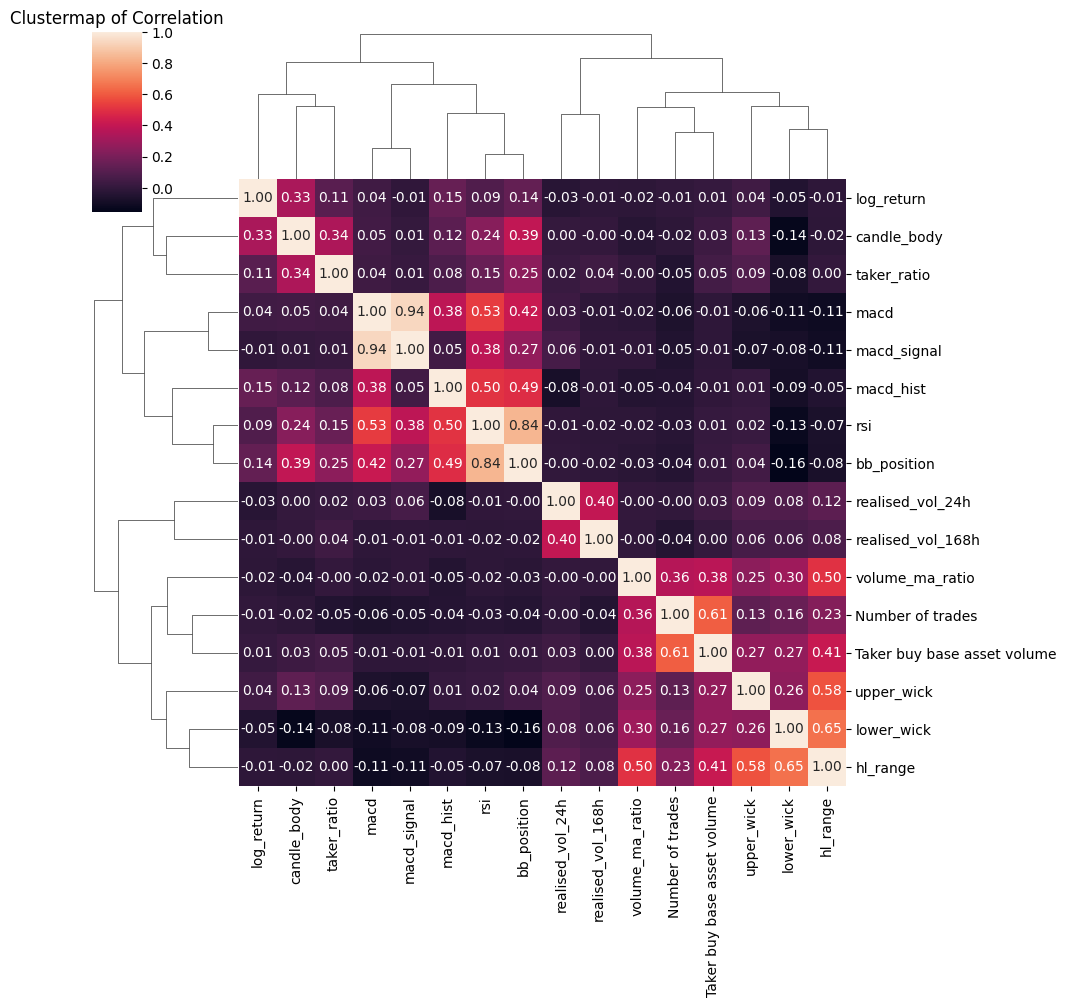

In [ ]:
plt.figure(figsize=(40,40))
sns.clustermap((A.drop({'Open time','Close time'} ,axis=1).corr()),fmt='.2f', annot=True)
plt.title('Clustermap of Correlation')
plt.show()

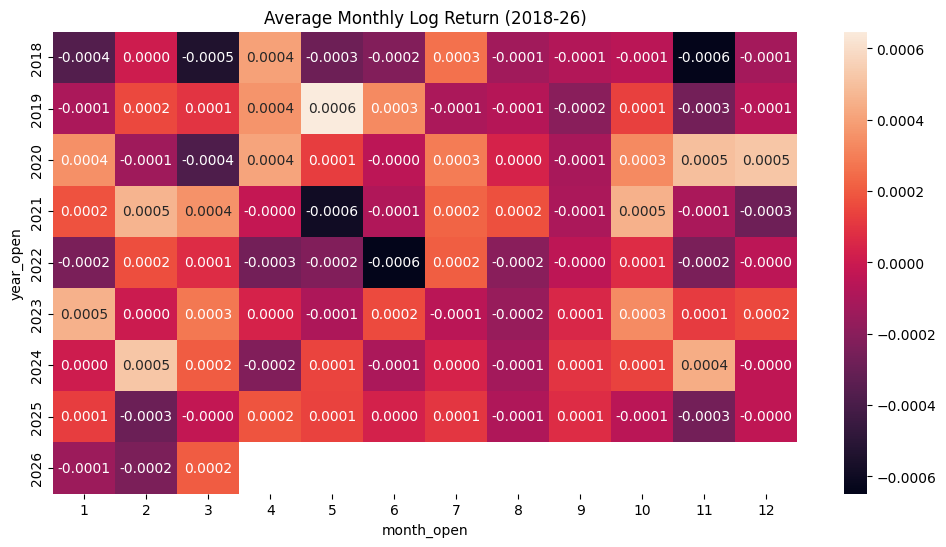

In [ ]:
plt.figure(figsize=(12,6))
sns.heatmap(df.groupby(['year_open', 'month_open'])['log_return'].mean().unstack(), annot=True, fmt='.4f')
plt.title('Average Monthly Log Return (2018-26)')
plt.show()

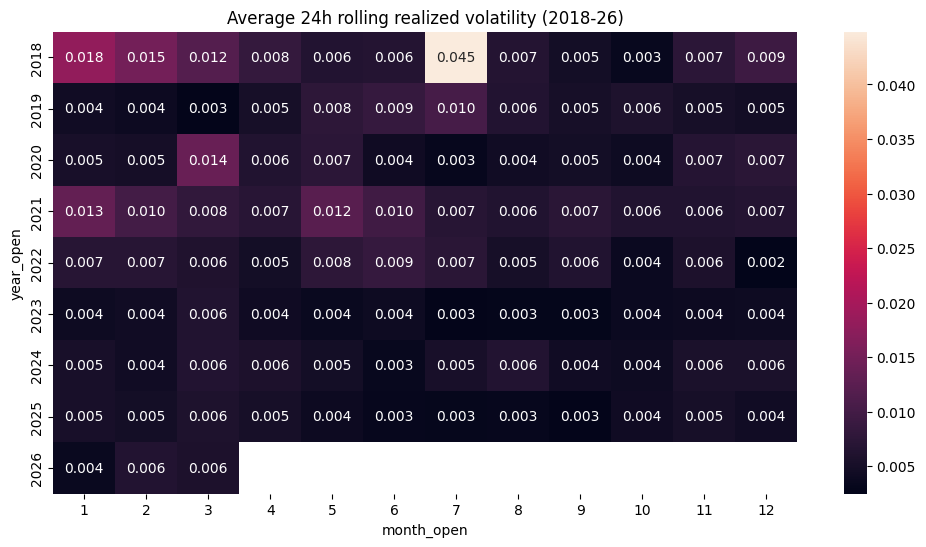

In [ ]:
plt.figure(figsize=(12,6))
sns.heatmap(df.groupby(['year_open', 'month_open'])['realised_vol_24h'].mean().unstack(), annot=True, fmt='.3f')
plt.title('Average 24h rolling realized volatility (2018-26)')
plt.show()

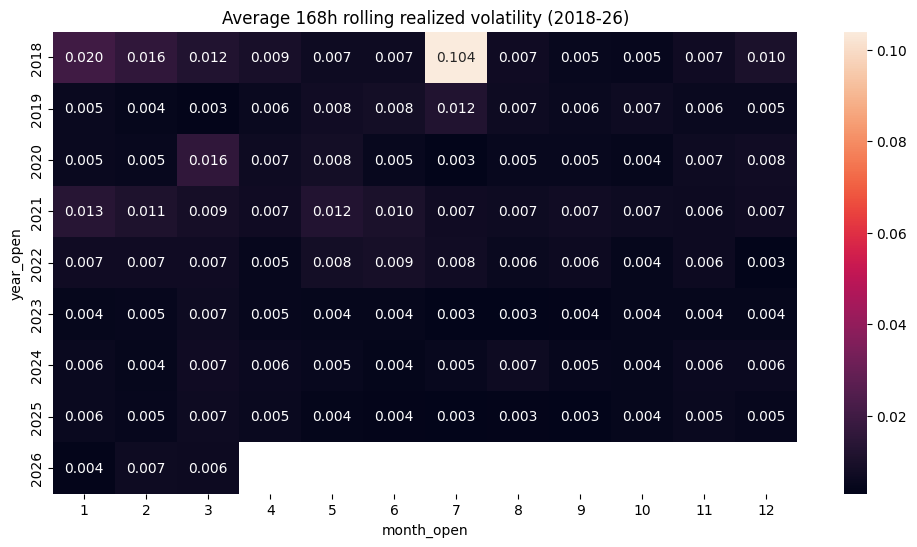

In [ ]:
plt.figure(figsize=(12,6))
sns.heatmap(df.groupby(['year_open', 'month_open'])['realised_vol_168h'].mean().unstack(), annot=True, fmt='.3f')
plt.title('Average 168h rolling realized volatility (2018-26)')
plt.show()

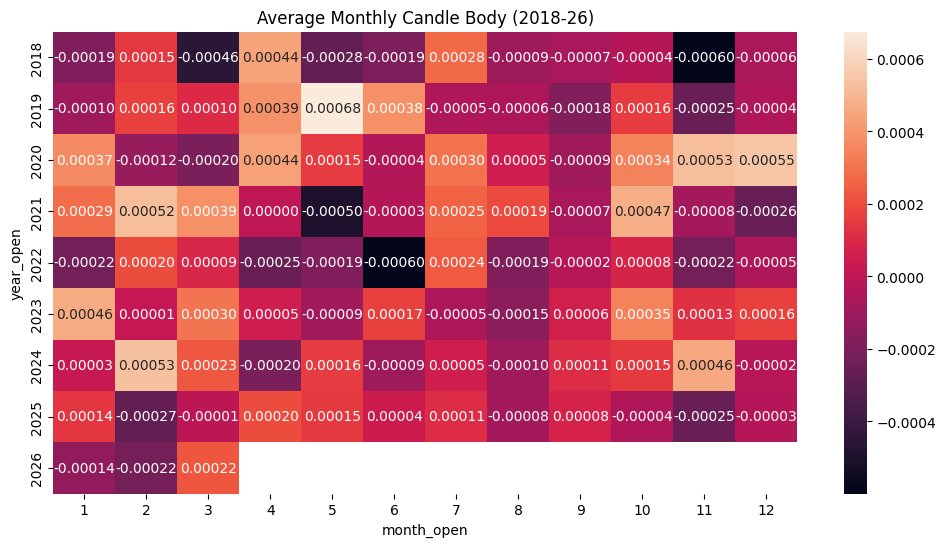

In [ ]:
plt.figure(figsize=(12,6))
sns.heatmap(df.groupby(['year_open', 'month_open'])['candle_body'].mean().unstack(), annot=True, fmt='.5f')
plt.title('Average Monthly Candle Body (2018-26)')
plt.show()

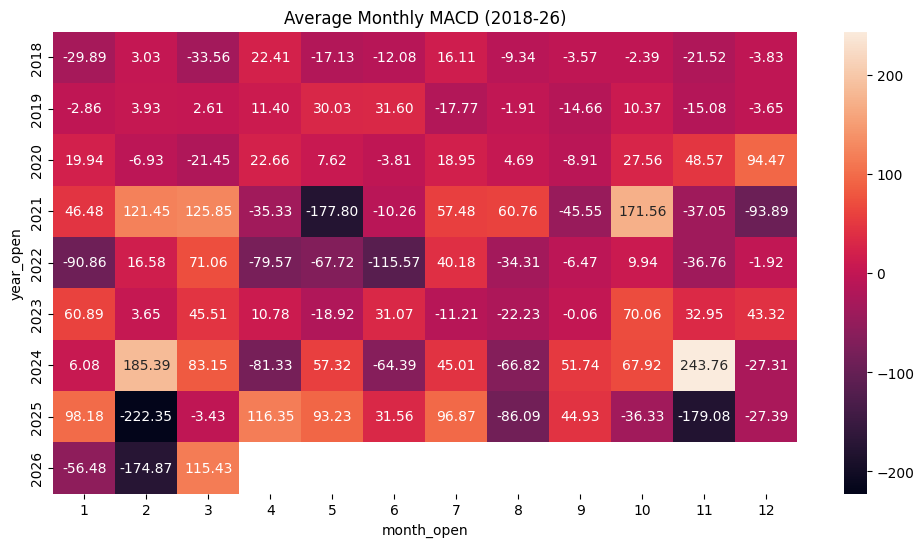

In [ ]:
plt.figure(figsize=(12,6))
sns.heatmap(df.groupby(['year_open', 'month_open'])['macd'].mean().unstack(), annot=True, fmt='.2f')
plt.title('Average Monthly MACD (2018-26)')
plt.show()

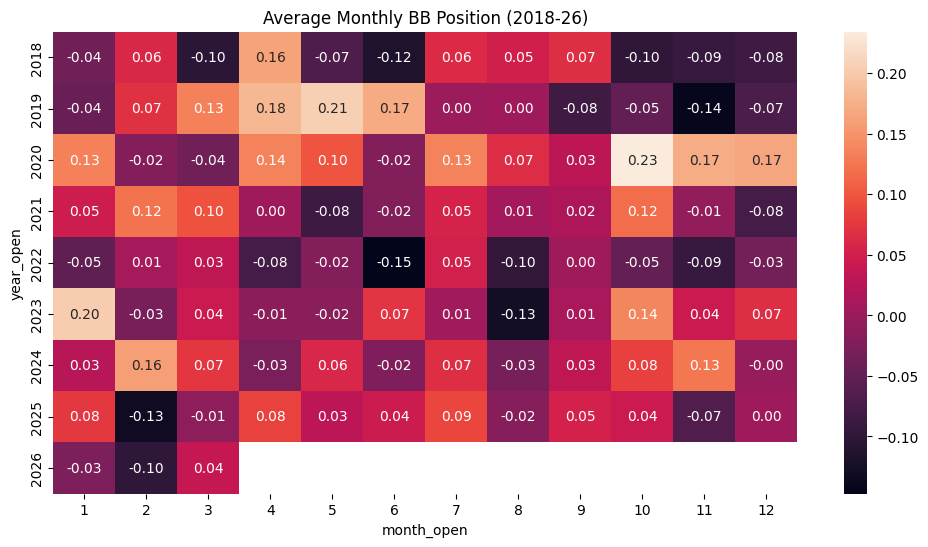

In [ ]:
plt.figure(figsize=(12,6))
sns.heatmap(df.groupby(['year_open', 'month_open'])['bb_position'].mean().unstack(), annot=True, fmt='.2f')
plt.title('Average Monthly BB Position (2018-26)')
plt.show()

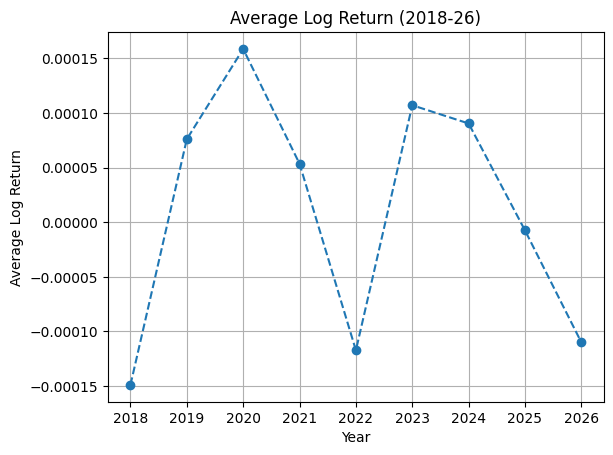

In [ ]:
plt.plot(df.groupby(['year_open'])['log_return'].mean(), '--o')
plt.grid()
plt.xlabel('Year')
plt.ylabel('Average Log Return')
plt.title('Average Log Return (2018-26)')
plt.show()

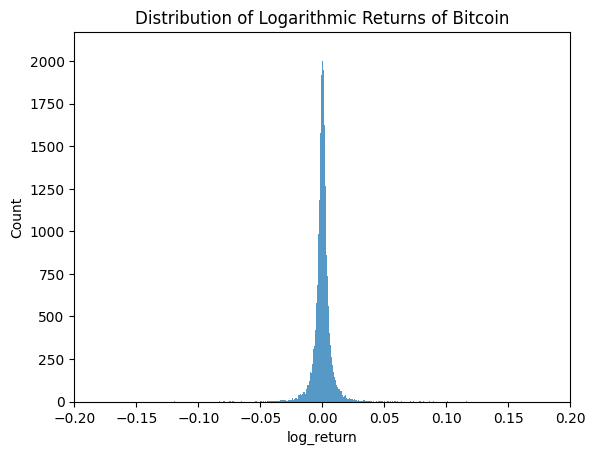

In [ ]:
sns.histplot(x='log_return', data=A)
plt.xlim(-0.2,0.2)
plt.title('Distribution of Logarithmic Returns of Bitcoin')
plt.show()

Statistics EDA

In [ ]:
from statsmodels.tsa.stattools import adfuller
result = adfuller(A['log_return'].dropna())
print(f'ADF p-value: {result[1]}')


ADF p-value: 0.0


In [ ]:
from statsmodels.stats.diagnostic import het_arch
stat, p, _, _ = het_arch(df['log_return'].dropna())
print(f'ARCH test p-value: {p}')

ARCH test p-value: 0.0


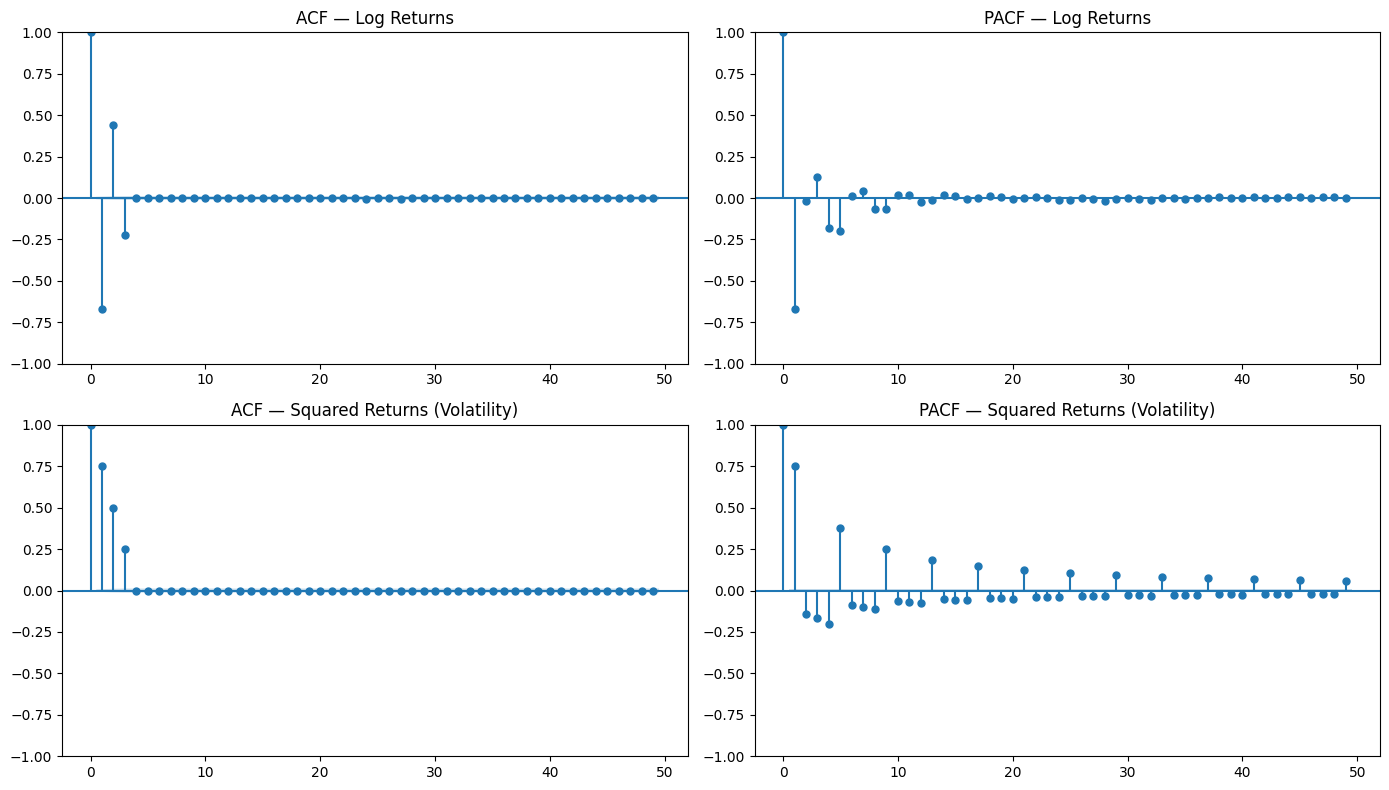

In [ ]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
fig, axes = plt.subplots(2, 2, figsize=(14, 8))
plot_acf(df['log_return'].dropna(), ax=axes[0,0], title='ACF — Log Returns')
plot_pacf(df['log_return'].dropna(), ax=axes[0,1], title='PACF — Log Returns')
plot_acf(df['log_return'].dropna()**2, ax=axes[1,0], title='ACF — Squared Returns (Volatility)')
plot_pacf(df['log_return'].dropna()**2, ax=axes[1,1], title='PACF — Squared Returns (Volatility)')
plt.tight_layout()
plt.show()

ADF test (H0: unit root): p ≈ 0 → reject. Log returns are stationary.
Engle's ARCH test (H0: no volatility clustering): p ≈ 0 → reject.

In [ ]:
A.columns

Index(['Open time', 'Close time', 'Number of trades',
       'Taker buy base asset volume', 'log_return', 'realised_vol_24h',
       'realised_vol_168h', 'candle_body', 'upper_wick', 'lower_wick',
       'hl_range', 'taker_ratio', 'volume_ma_ratio', 'rsi', 'macd',
       'macd_signal', 'macd_hist', 'bb_position'],
      dtype='object')

Preprocessing for LSTM

In [ ]:
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, BatchNormalization, Layer, LayerNormalization
from tensorflow.keras.callbacks import EarlyStopping

In [ ]:
A = A.set_index('Open time').sort_index()

In [ ]:
A.drop('Close time', axis=1, inplace=True)

In [ ]:
A.isnull().sum()

,0
Number of trades,0
Taker buy base asset volume,0
log_return,1
realised_vol_24h,24
realised_vol_168h,168
candle_body,0
upper_wick,0
lower_wick,0
hl_range,0
taker_ratio,3


1. Forecasting Log Returns

In [ ]:
A.dropna(inplace=True)

In [ ]:
A['target'] = A['log_return'].shift(-1)


In [ ]:
feature_cols = [
    'log_return', 'realised_vol_24h', 'realised_vol_168h',
    'candle_body', 'upper_wick', 'lower_wick', 'hl_range',
    'taker_ratio', 'volume_ma_ratio', 'rsi',
    'macd', 'macd_signal', 'macd_hist', 'bb_position',
    'Number of trades'
]
A_model = A[feature_cols + ['target']].dropna()

# Temporal train/val/test split
n = len(A_model)
train_end = int(n * 0.7)
val_end   = int(n * 0.85)

train_df = A_model.iloc[:train_end]
val_df   = A_model.iloc[train_end:val_end]
test_df  = A_model.iloc[val_end:]

y_train = train_df['target'].values
y_val   = val_df['target'].values
y_test  = test_df['target'].values

In [ ]:
scaler = StandardScaler()
X_train = scaler.fit_transform(train_df[feature_cols])
X_val   = scaler.transform(val_df[feature_cols])
X_test  = scaler.transform(test_df[feature_cols])

In [ ]:
def create_windows(X, y, window=48):
    Xs, ys = [], []
    for i in range(len(X) - window):
        Xs.append(X[i : i+window])
        ys.append(y[i + window])
    return np.array(Xs), np.array(ys)

WINDOW = 48

X_tr, y_tr = create_windows(X_train, y_train, WINDOW)
X_va, y_va = create_windows(X_val,   y_val,   WINDOW)
X_te, y_te = create_windows(X_test,  y_test,  WINDOW)
print(X_tr.shape)
print(y_tr.shape)

(50079, 48, 15)
(50079,)


In [ ]:
tf.keras.backend.clear_session()
def build_lstm(input_shape):
    model = Sequential([
        LSTM(128, return_sequences=True, input_shape=input_shape, activation='tanh'),
        Dropout(0.2),

        LSTM(64),
        Dropout(0.2),

        Dense(1)
    ])
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=0.0005),
        loss='mae',
        metrics=['mae']
    )
    return model

model = build_lstm(input_shape=(WINDOW, len(feature_cols)))
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 168, 128)       │        73,728 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 168, 128)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 64)             │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 123,201 (481.25 KB)

 Trainable params: 123,201 (481.25 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
early_stop = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True
)

lr_schedule = tf.keras.callbacks.ReduceLROnPlateau(
    monitor='val_loss', factor=0.5, patience=3, min_lr=1e-6, verbose=1
)

history = model.fit(
    X_tr, y_tr,
    validation_data=(X_va, y_va),
    epochs=50,
    batch_size=128,
    callbacks=[early_stop, lr_schedule],
    verbose=1
)

Epoch 1/50
391/391 ━━━━━━━━━━━━━━━━━━━━ 12s 26ms/step - loss: 0.0208 - mae: 0.0208 - val_loss: 0.0053 - val_mae: 0.0053 - learning_rate: 5.0000e-04
Epoch 2/50
391/391 ━━━━━━━━━━━━━━━━━━━━ 9s 24ms/step - loss: 0.0081 - mae: 0.0081 - val_loss: 0.0047 - val_mae: 0.0047 - learning_rate: 5.0000e-04
Epoch 3/50
391/391 ━━━━━━━━━━━━━━━━━━━━ 9s 24ms/step - loss: 0.0064 - mae: 0.0064 - val_loss: 0.0038 - val_mae: 0.0038 - learning_rate: 5.0000e-04
Epoch 4/50
391/391 ━━━━━━━━━━━━━━━━━━━━ 9s 22ms/step - loss: 0.0057 - mae: 0.0057 - val_loss: 0.0037 - val_mae: 0.0037 - learning_rate: 5.0000e-04
Epoch 5/50
391/391 ━━━━━━━━━━━━━━━━━━━━ 9s 23ms/step - loss: 0.0053 - mae: 0.0053 - val_loss: 0.0036 - val_mae: 0.0036 - learning_rate: 5.0000e-04
Epoch 6/50
391/391 ━━━━━━━━━━━━━━━━━━━━ 9s 23ms/step - loss: 0.0051 - mae: 0.0051 - val_loss: 0.0036 - val_mae: 0.0036 - learning_rate: 5.0000e-04
Epoch 7/50
391/391 ━━━━━━━━━━━━━━━━━━━━ 10s 23ms/step - loss: 0.0050 - mae: 0.0050 - val_loss: 0.0036 - val_mae: 0.00

In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
y_pred = model.predict(X_te).flatten()
y_true = y_te

mae     = mean_absolute_error(y_true, y_pred)
rmse    = np.sqrt(mean_squared_error(y_true, y_pred))
dir_acc = np.mean(np.sign(y_pred) == np.sign(y_true))

print(f'MAE:             {mae:.6f}')
print(f'RMSE:            {rmse:.6f}')
print(f'Directional Acc: {dir_acc:.2%}')


331/331 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step
MAE:             0.003193
RMSE:            0.004937
Directional Acc: 51.81%


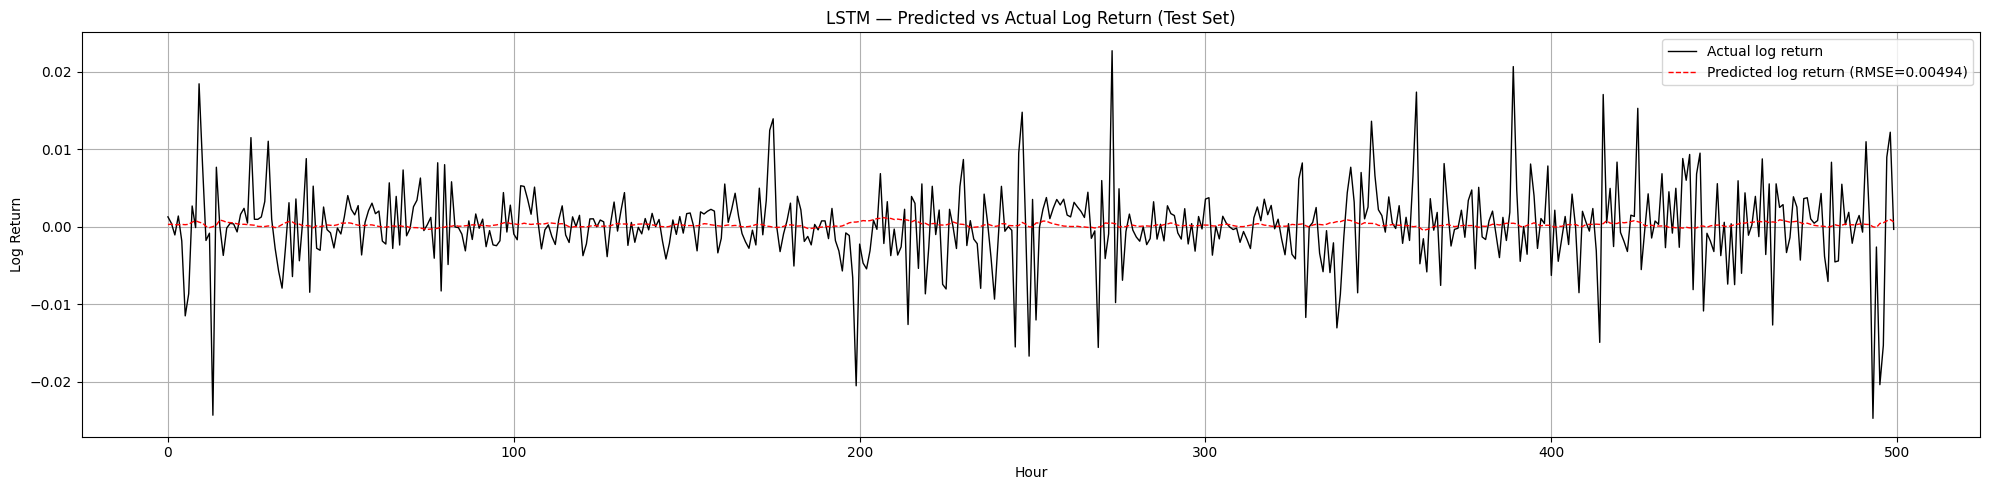

In [ ]:
plt.figure(figsize=(20, 5))
plt.plot(y_true[:500], label='Actual log return', color='black', lw=1)
plt.plot(y_pred[:500], label=f'Predicted log return (RMSE={rmse:.5f})', color='red', linestyle='--', lw=1)
plt.title('LSTM — Predicted vs Actual Log Return (Test Set)')
plt.xlabel('Hour')
plt.ylabel('Log Return')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

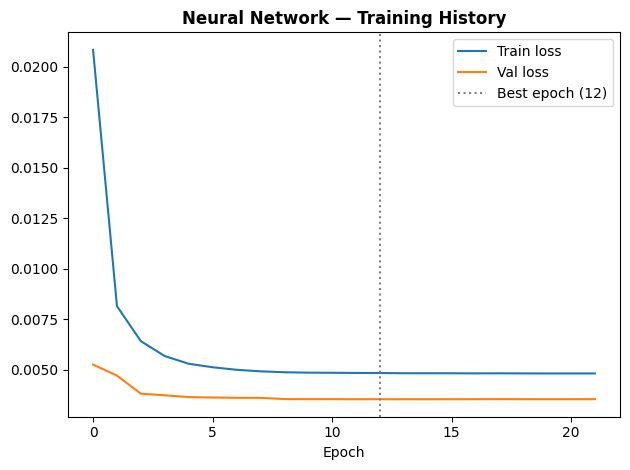

In [ ]:
plt.plot(history.history['loss'],     label='Train loss')
plt.plot(history.history['val_loss'], label='Val loss')
best_epoch_a = np.argmin(history.history['val_loss']) + 1
plt.axvline(x=best_epoch_a, color='grey', linestyle=':', label=f'Best epoch ({best_epoch_a})')
plt.xlabel('Epoch')
plt.legend()
plt.title('Neural Network — Training History', fontweight='bold')
plt.tight_layout()
plt.show()

2. Forecasting 24h Volatility

In [ ]:
B = A.drop('target',axis=1)
B.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 71611 entries, 2018-01-08 01:00:00 to 2026-03-15 21:00:00
Data columns (total 16 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   Number of trades             71611 non-null  int64  
 1   Taker buy base asset volume  71611 non-null  float64
 2   log_return                   71611 non-null  float64
 3   realised_vol_24h             71611 non-null  float64
 4   realised_vol_168h            71611 non-null  float64
 5   candle_body                  71611 non-null  float64
 6   upper_wick                   71611 non-null  float64
 7   lower_wick                   71611 non-null  float64
 8   hl_range                     71611 non-null  float64
 9   taker_ratio                  71611 non-null  float64
 10  volume_ma_ratio              71611 non-null  float64
 11  rsi                          71611 non-null  float64
 12  macd                         71611 non-

In [ ]:
B['target'] = np.log(B['realised_vol_24h'].shift(-1))
B.head(2)

,Number of trades,Taker buy base asset volume,log_return,realised_vol_24h,realised_vol_168h,candle_body,upper_wick,lower_wick,hl_range,taker_ratio,volume_ma_ratio,rsi,macd,macd_signal,macd_hist,bb_position,target
Open time,,,,,,,,,,,,,,,,,
2018-01-08 01:00:00,8668,447.956068,-0.006220,0.010866,0.012775,-0.005762,0.003756,0.012236,0.021754,0.509734,1.694943,33.665379,-154.042373,-116.804654,-37.237719,-0.766044,-4.504740
2018-01-08 02:00:00,5479,451.048469,0.011748,0.011056,0.012650,0.011817,0.003951,0.001266,0.017034,0.589004,1.482421,40.351067,-152.496838,-123.943090,-28.553747,-0.423128,-4.433387


In [ ]:
B.columns

Index(['Number of trades', 'Taker buy base asset volume', 'log_return',
       'realised_vol_24h', 'realised_vol_168h', 'candle_body', 'upper_wick',
       'lower_wick', 'hl_range', 'taker_ratio', 'volume_ma_ratio', 'rsi',
       'macd', 'macd_signal', 'macd_hist', 'bb_position', 'target'],
      dtype='object')

In [ ]:
B.isnull().sum()

,0
Number of trades,0
Taker buy base asset volume,0
log_return,0
realised_vol_24h,0
realised_vol_168h,0
candle_body,0
upper_wick,0
lower_wick,0
hl_range,0
taker_ratio,0


In [ ]:
feature_cols = [
    'log_return', 'realised_vol_24h', 'realised_vol_168h',
    'candle_body', 'upper_wick', 'lower_wick', 'hl_range',
    'taker_ratio', 'volume_ma_ratio', 'rsi',
    'macd', 'macd_signal', 'macd_hist', 'bb_position',
    'Number of trades'
]

B_model = B[feature_cols + ['target']].dropna()



# Temporal train/val/test split
n = len(B_model)
train_end_b = int(n * 0.7)
val_end_b   = int(n * 0.85)

train_df_b = B_model.iloc[:train_end_b]
val_df_b   = B_model.iloc[train_end_b:val_end_b]
test_df_b  = B_model.iloc[val_end_b:]

y_train_b = train_df_b['target'].values
y_val_b   = val_df_b['target'].values
y_test_b  = test_df_b['target'].values

In [ ]:
scaler_b = StandardScaler()
X_train_b = scaler_b.fit_transform(train_df_b[feature_cols])
X_val_b   = scaler_b.transform(val_df_b[feature_cols])
X_test_b  = scaler_b.transform(test_df_b[feature_cols])

Mean:     -5.316781
Std:      0.618943
Skewness: 0.247
Min:      -7.696095
Max:      0.153015


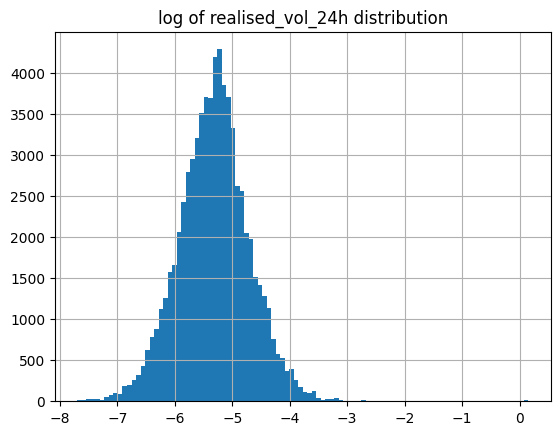

In [ ]:
target = B['target'].dropna()

print(f'Mean:     {target.mean():.6f}')
print(f'Std:      {target.std():.6f}')
print(f'Skewness: {target.skew():.3f}')
print(f'Min:      {target.min():.6f}')
print(f'Max:      {target.max():.6f}')

target.hist(bins=100)
plt.title('log of realised_vol_24h distribution')
plt.show()


In [ ]:
WINDOW_b = 24

X_tr_b, y_tr_b = create_windows(X_train_b, y_train_b, WINDOW_b)
X_va_b, y_va_b = create_windows(X_val_b,   y_val_b,   WINDOW_b)
X_te_b, y_te_b = create_windows(X_test_b,  y_test_b,  WINDOW_b)
print(X_tr_b.shape)
print(y_tr_b.shape)

(50103, 24, 15)
(50103,)


In [ ]:
tf.keras.backend.clear_session()
def build_lstm_b(input_shape):
    model = Sequential([
        LSTM(128, return_sequences=True, input_shape=input_shape, activation='tanh'),
        Dropout(0.2),

        LSTM(64),
        Dropout(0.2),

        Dense(1)
    ])
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=0.0005),
        loss='mae',
        metrics=['mae']
    )
    return model

model_b = build_lstm_b(input_shape=(WINDOW_b, len(feature_cols)))
model_b.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 24, 128)        │        73,728 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 24, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 64)             │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 123,201 (481.25 KB)

 Trainable params: 123,201 (481.25 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
early_stop = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True
)

lr_schedule = tf.keras.callbacks.ReduceLROnPlateau(
    monitor='val_loss', factor=0.5, patience=3, min_lr=1e-6, verbose=1
)

history_b = model_b.fit(
    X_tr_b, y_tr_b,
    validation_data=(X_va_b, y_va_b),
    epochs=50,
    batch_size=128,
    callbacks=[early_stop, lr_schedule],
    verbose=1
)

Epoch 1/50
392/392 ━━━━━━━━━━━━━━━━━━━━ 12s 16ms/step - loss: 0.6114 - mae: 0.6114 - val_loss: 0.1617 - val_mae: 0.1617 - learning_rate: 5.0000e-04
Epoch 2/50
392/392 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - loss: 0.3147 - mae: 0.3147 - val_loss: 0.1252 - val_mae: 0.1252 - learning_rate: 5.0000e-04
Epoch 3/50
392/392 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - loss: 0.2970 - mae: 0.2970 - val_loss: 0.1136 - val_mae: 0.1136 - learning_rate: 5.0000e-04
Epoch 4/50
392/392 ━━━━━━━━━━━━━━━━━━━━ 6s 9ms/step - loss: 0.2886 - mae: 0.2886 - val_loss: 0.1321 - val_mae: 0.1321 - learning_rate: 5.0000e-04
Epoch 5/50
392/392 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - loss: 0.2810 - mae: 0.2810 - val_loss: 0.1191 - val_mae: 0.1191 - learning_rate: 5.0000e-04
Epoch 6/50
392/392 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - loss: 0.2782 - mae: 0.2782 - val_loss: 0.1036 - val_mae: 0.1036 - learning_rate: 5.0000e-04
Epoch 7/50
392/392 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - loss: 0.2760 - mae: 0.2760 - val_loss: 0.0945 - val_mae: 0.0945 - 

In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
y_pred_b = np.exp(model_b.predict(X_te_b).flatten())
y_true_b = np.exp(y_te_b)

mae_b     = mean_absolute_error(y_true_b, y_pred_b)
rmse_b    = np.sqrt(mean_squared_error(y_true_b, y_pred_b))

print(f'MAE:             {mae_b:.6f}')
print(f'RMSE:            {rmse_b:.6f}')

335/335 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step
MAE:             0.000400
RMSE:            0.000607


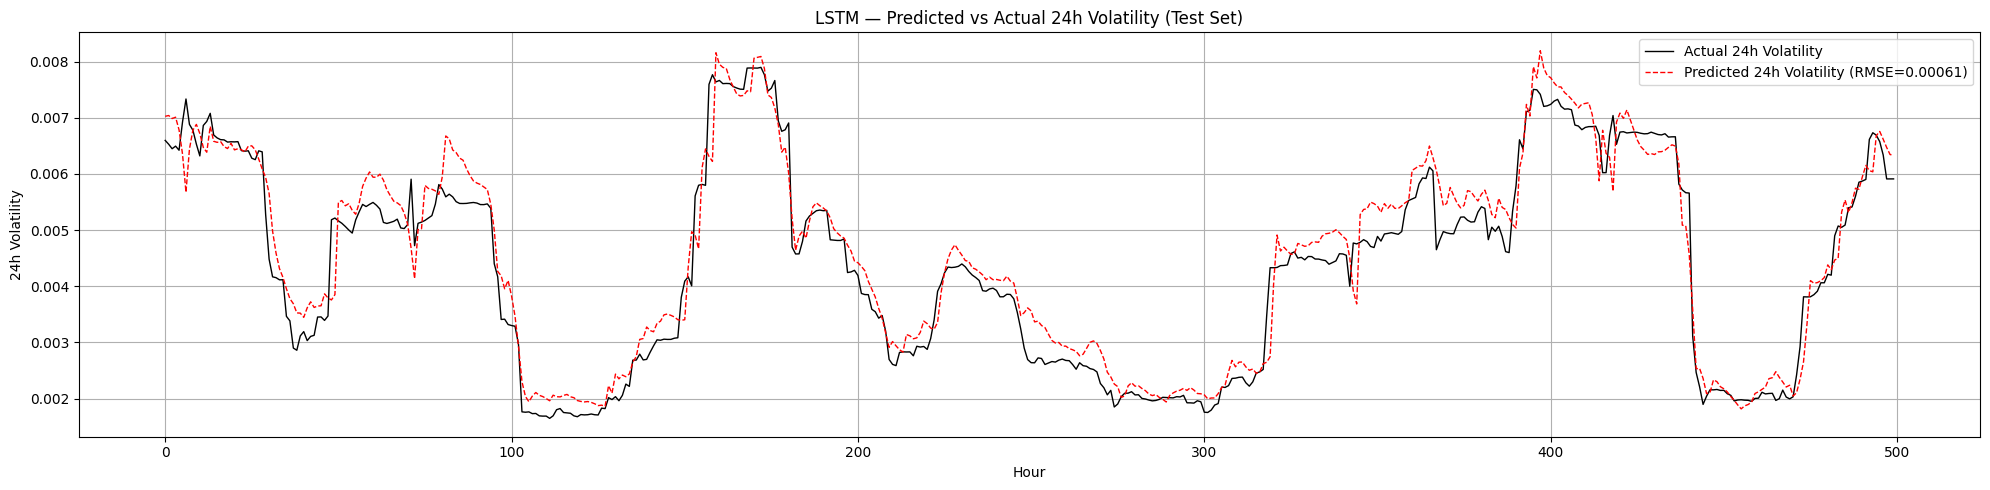

In [ ]:
plt.figure(figsize=(20, 5))
plt.plot(y_true_b[:500], label='Actual 24h Volatility', color='black', lw=1)
plt.plot(y_pred_b[:500], label=f'Predicted 24h Volatility (RMSE={rmse_b:.5f})', color='red', linestyle='--', lw=1)
plt.title('LSTM — Predicted vs Actual 24h Volatility (Test Set)')
plt.xlabel('Hour')
plt.ylabel('24h Volatility')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

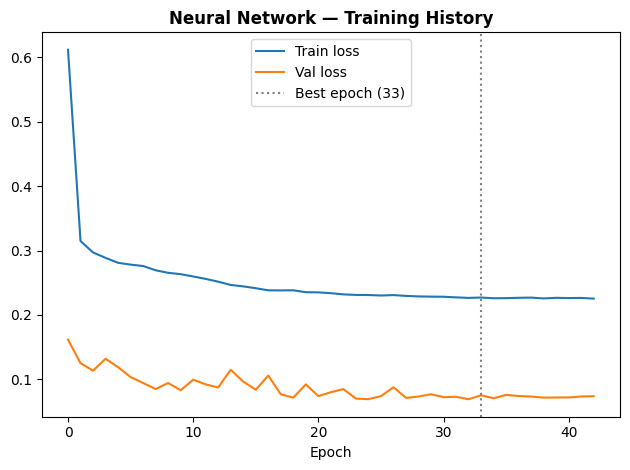

In [ ]:
plt.plot(history_b.history['loss'],     label='Train loss')
plt.plot(history_b.history['val_loss'], label='Val loss')
best_epoch_b = np.argmin(history_b.history['val_loss']) + 1
plt.axvline(x=best_epoch_b, color='grey', linestyle=':', label=f'Best epoch ({best_epoch_b})')
plt.xlabel('Epoch')
plt.legend()
plt.title('Neural Network — Training History', fontweight='bold')
plt.tight_layout()
plt.show()


Modelling with a custom Transformer

In [ ]:
from tensorflow.keras.models import Model
from tensorflow.keras import Input


In [ ]:
class MultiHeadSelfAttention(Layer):
    def __init__(self, embed_dim, num_heads=8):
        super(MultiHeadSelfAttention, self).__init__()
        self.embed_dim = embed_dim        # Dimensionality of input embeddings
        self.num_heads = num_heads        # Number of parallel attention mechanisms
        self.projection_dim = embed_dim // num_heads  # Dimension per head

        if embed_dim % num_heads != 0:
            raise ValueError(
                f"embed_dim ({embed_dim}) must be divisible by num_heads ({num_heads})"
            )

        self.query_dense = Dense(embed_dim)
        self.key_dense = Dense(embed_dim)
        self.value_dense = Dense(embed_dim)   # Three Dense layers create Q, K, V projections
        self.combine_heads = Dense(embed_dim)   # Combines Q, K, V

    # compute attention score #
    def attention(self, query, key, value):
      score = tf.matmul(query, key, transpose_b=True)   # Compute dot products between queries and keys

      dim_key = tf.cast(tf.shape(key)[-1], tf.float32)
      scaled_score = score / tf.math.sqrt(dim_key)     # to prevent softmax from saturating

      weights = tf.nn.softmax(scaled_score, axis=-1)    # softmax gives probability distribution

      output = tf.matmul(weights, value)    # Multiply attention weights with values to get output
      return output, weights

    # head splitting #
    def split_heads(self, x, batch_size):
      x = tf.reshape(x, (batch_size, -1, self.num_heads, self.projection_dim))    # Each head focuses on different aspects
      return tf.transpose(x, perm=[0, 2, 1, 3])

    def call(self, inputs):
      batch_size = tf.shape(inputs)[0]

      query = self.query_dense(inputs)
      key = self.key_dense(inputs)
      value = self.value_dense(inputs)

      query = self.split_heads(query, batch_size)
      key = self.split_heads(key, batch_size)
      value = self.split_heads(value, batch_size)

      attention_output, _ = self.attention(query, key, value)

      attention_output = tf.transpose(attention_output, perm=[0, 2, 1, 3])
      concat_attention = tf.reshape(attention_output, (batch_size, -1, self.embed_dim))   # Final combination layer learns optimal head integration

      return self.combine_heads(concat_attention)

class TransformerBlock(Layer):
    def __init__(self, embed_dim, num_heads, ff_dim, rate=0.1):
        super(TransformerBlock, self).__init__()
        self.att = MultiHeadSelfAttention(embed_dim, num_heads)
        self.ffn = tf.keras.Sequential([
            Dense(ff_dim, activation="relu"),
            Dense(embed_dim),
        ])
        self.layernorm1 = LayerNormalization(epsilon=1e-6)
        self.layernorm2 = LayerNormalization(epsilon=1e-6)
        self.dropout1 = Dropout(rate)
        self.dropout2 = Dropout(rate)

    def call(self, inputs, training=False):
        attn_output = self.att(inputs)
        attn_output = self.dropout1(attn_output, training=training)
        out1 = self.layernorm1(inputs + attn_output)

        ffn_output = self.ffn(out1)
        ffn_output = self.dropout2(ffn_output, training=training)
        return self.layernorm2(out1 + ffn_output)

class PositionalEncoding(Layer):      # Positional Encoding #
    def __init__(self, max_len, embed_dim):
        super().__init__()
        self.embed_dim = embed_dim
        p, i = np.meshgrid(np.arange(max_len), np.arange(embed_dim // 2))
        angles = p / np.power(10000, 2 * i / embed_dim)
        pos_encoding = np.zeros((max_len, embed_dim))
        pos_encoding[:, 0::2] = np.sin(angles.T)
        pos_encoding[:, 1::2] = np.cos(angles.T)
        self.pos_encoding = tf.cast(pos_encoding[np.newaxis, ...], tf.float32)

    def call(self, x):
        return x + self.pos_encoding[:, :tf.shape(x)[1], :]


class TransformerEncoder(Layer):
    def __init__(self, num_layers, embed_dim, num_heads, ff_dim, rate=0.1):
        super(TransformerEncoder, self).__init__()
        self.enc_layers = [TransformerBlock(embed_dim, num_heads, ff_dim, rate)
                           for _ in range(num_layers)]
        self.dropout = Dropout(rate)

    def call(self, inputs, training=False):
        x = inputs
        x = self.dropout(x, training=training)

        for layer in self.enc_layers:
            x = layer(x, training=training)
        return x

In [ ]:
def build_model_t_a(WINDOW, embed_dim=128, num_heads=4, ff_dim=256,
                num_layers=2, dropout_rate=0.1):

    inputs = Input(shape=(WINDOW, len(feature_cols)))

    x = Dense(embed_dim)(inputs)
    x = PositionalEncoding(WINDOW, embed_dim)(x)
    encoder = TransformerEncoder(num_layers, embed_dim, num_heads, ff_dim, dropout_rate)
    x = encoder(x)

    x = x[:, -1, :]
    x = Dropout(dropout_rate)(x)
    outputs = Dense(1)(x)

    return Model(inputs, outputs)

1. Predicting Log Returns

In [ ]:
tf.keras.backend.clear_session()

model_t_a = build_model_t_a(WINDOW, embed_dim=128, num_heads=4,
                        ff_dim=256, num_layers=2, dropout_rate=0.2)
model_t_a.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.0005), loss='mae', metrics=['mae'])

model_t_a.summary()

Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 48, 15)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 48, 128)        │         2,048 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ positional_encoding             │ (None, 48, 128)        │             0 │
│ (PositionalEncoding)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ transformer_encoder             │ (None, 48, 128)        │       264,960 │
│ (TransformerEncoder)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ get_item (GetItem)              │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 267,137 (1.02 MB)

 Trainable params: 267,137 (1.02 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
early_stop = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True
)

lr_schedule = tf.keras.callbacks.ReduceLROnPlateau(
    monitor='val_loss', factor=0.5, patience=3, min_lr=1e-6, verbose=1
)

history_t_a = model_t_a.fit(
    X_tr, y_tr,
    validation_data=(X_va, y_va),
    epochs=50,
    batch_size=128,
    callbacks=[early_stop, lr_schedule],
    verbose=1
)

Epoch 1/50
392/392 ━━━━━━━━━━━━━━━━━━━━ 35s 34ms/step - loss: 0.1945 - mae: 0.1945 - val_loss: 0.0234 - val_mae: 0.0234 - learning_rate: 5.0000e-04
Epoch 2/50
392/392 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - loss: 0.0314 - mae: 0.0314 - val_loss: 0.0108 - val_mae: 0.0108 - learning_rate: 5.0000e-04
Epoch 3/50
392/392 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step - loss: 0.0217 - mae: 0.0217 - val_loss: 0.0050 - val_mae: 0.0050 - learning_rate: 5.0000e-04
Epoch 4/50
392/392 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - loss: 0.0183 - mae: 0.0183 - val_loss: 0.0041 - val_mae: 0.0041 - learning_rate: 5.0000e-04
Epoch 5/50
392/392 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - loss: 0.0162 - mae: 0.0162 - val_loss: 0.0042 - val_mae: 0.0042 - learning_rate: 5.0000e-04
Epoch 6/50
392/392 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step - loss: 0.0139 - mae: 0.0139 - val_loss: 0.0053 - val_mae: 0.0053 - learning_rate: 5.0000e-04
Epoch 7/50
390/392 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0123 - mae: 0.0123
Epoch 7: ReduceLROnPlateau reducing

In [ ]:
y_pred_t_a = model_t_a.predict(X_te).flatten()
y_true = y_te

mae_t_a     = mean_absolute_error(y_true, y_pred_t_a)
rmse_t_a    = np.sqrt(mean_squared_error(y_true, y_pred_t_a))
dir_acc_t_a = np.mean(np.sign(y_pred_t_a) == np.sign(y_true))

print(f'MAE:             {mae_t_a:.6f}')
print(f'RMSE:            {rmse_t_a:.6f}')
print(f'Directional Acc: {dir_acc_t_a:.2%}')

335/335 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step
MAE:             0.003179
RMSE:            0.004912
Directional Acc: 51.32%


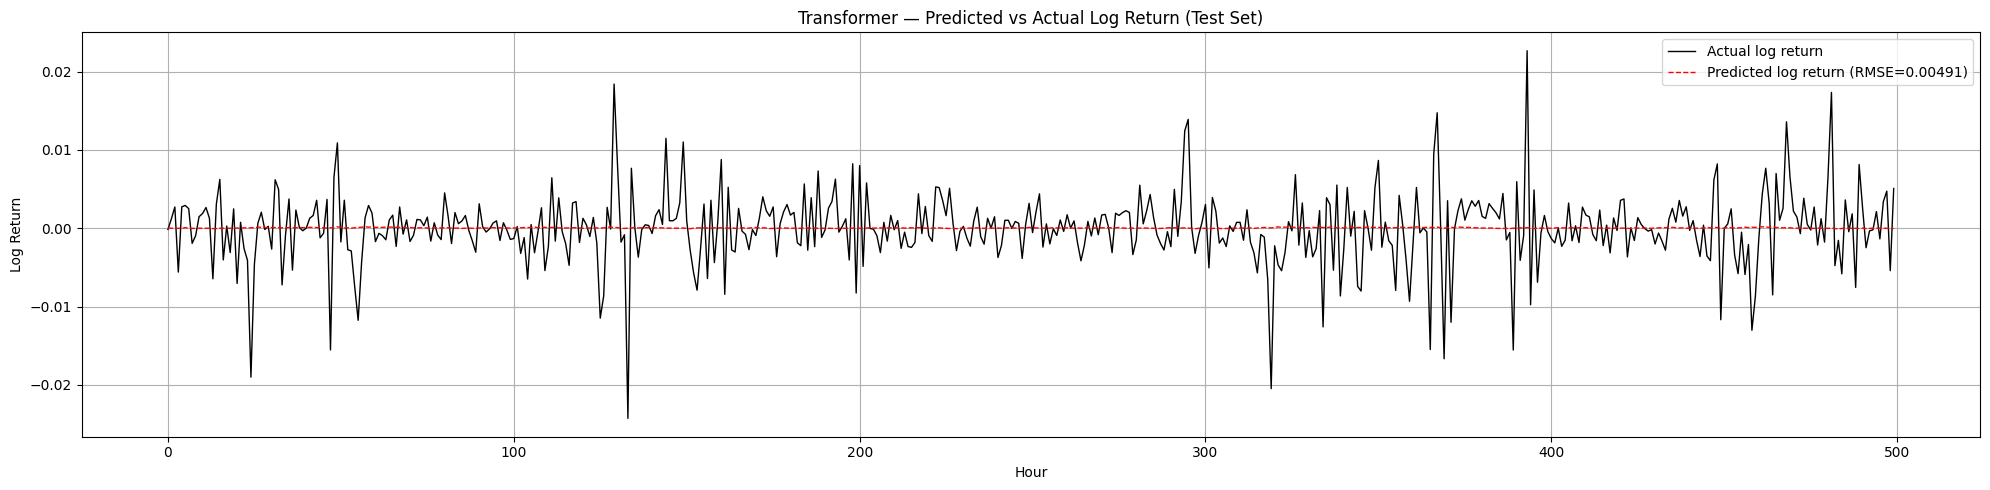

In [ ]:
plt.figure(figsize=(20, 5))
plt.plot(y_true[:500], label='Actual log return', color='black', lw=1)
plt.plot(y_pred_t_a[:500], label=f'Predicted log return (RMSE={rmse_t_a:.5f})', color='red', linestyle='--', lw=1)
plt.title('Transformer — Predicted vs Actual Log Return (Test Set)')
plt.xlabel('Hour')
plt.ylabel('Log Return')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

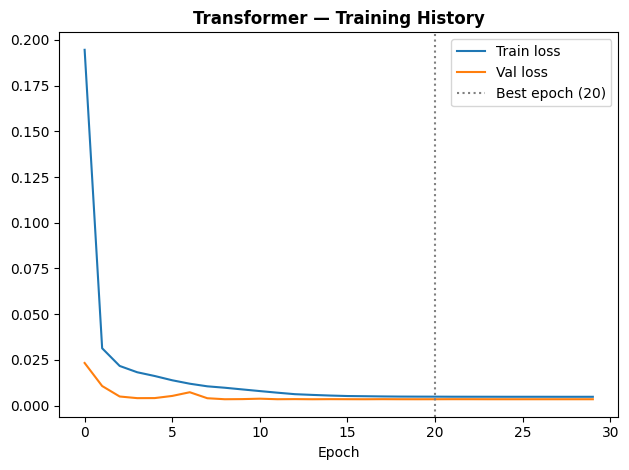

In [ ]:
plt.plot(history_t_a.history['loss'],     label='Train loss')
plt.plot(history_t_a.history['val_loss'], label='Val loss')
best_epoch_t_a = np.argmin(history_t_a.history['val_loss']) + 1
plt.axvline(x=best_epoch_t_a, color='grey', linestyle=':', label=f'Best epoch ({best_epoch_t_a})')
plt.xlabel('Epoch')
plt.legend()
plt.title('Transformer — Training History', fontweight='bold')
plt.tight_layout()
plt.show()

2. Predicting 24h Volatility

In [ ]:
tf.keras.backend.clear_session()

model_t_b = build_model_t_a(WINDOW_b, embed_dim=128, num_heads=4,
                        ff_dim=256, num_layers=2, dropout_rate=0.2)
model_t_b.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.0005), loss='mae', metrics=['mae'])

model_t_b.summary()

Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 24, 15)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 24, 128)        │         2,048 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ positional_encoding             │ (None, 24, 128)        │             0 │
│ (PositionalEncoding)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ transformer_encoder             │ (None, 24, 128)        │       264,960 │
│ (TransformerEncoder)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ get_item (GetItem)              │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 267,137 (1.02 MB)

 Trainable params: 267,137 (1.02 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
history_t_b = model_t_b.fit(
    X_tr_b, y_tr_b,
    validation_data=(X_va_b, y_va_b),
    epochs=50,
    batch_size=128,
    callbacks=[early_stop, lr_schedule],
    verbose=1
)

Epoch 1/50
392/392 ━━━━━━━━━━━━━━━━━━━━ 32s 31ms/step - loss: 0.4406 - mae: 0.4406 - val_loss: 0.4025 - val_mae: 0.4025 - learning_rate: 5.0000e-04
Epoch 2/50
392/392 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - loss: 0.2795 - mae: 0.2795 - val_loss: 0.6380 - val_mae: 0.6380 - learning_rate: 5.0000e-04
Epoch 3/50
391/392 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.2608 - mae: 0.2608
Epoch 3: ReduceLROnPlateau reducing learning rate to 0.0002500000118743628.
392/392 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - loss: 0.2589 - mae: 0.2589 - val_loss: 0.5724 - val_mae: 0.5724 - learning_rate: 5.0000e-04
Epoch 4/50
392/392 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - loss: 0.2459 - mae: 0.2459 - val_loss: 0.4302 - val_mae: 0.4302 - learning_rate: 2.5000e-04
Epoch 5/50
392/392 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - loss: 0.2399 - mae: 0.2399 - val_loss: 0.4938 - val_mae: 0.4938 - learning_rate: 2.5000e-04
Epoch 6/50
391/392 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.2372 - mae: 0.2372
Epoch 6: ReduceLROnPlateau reducing lear

MAE (bias corrected):  0.000554
RMSE (bias corrected): 0.000788


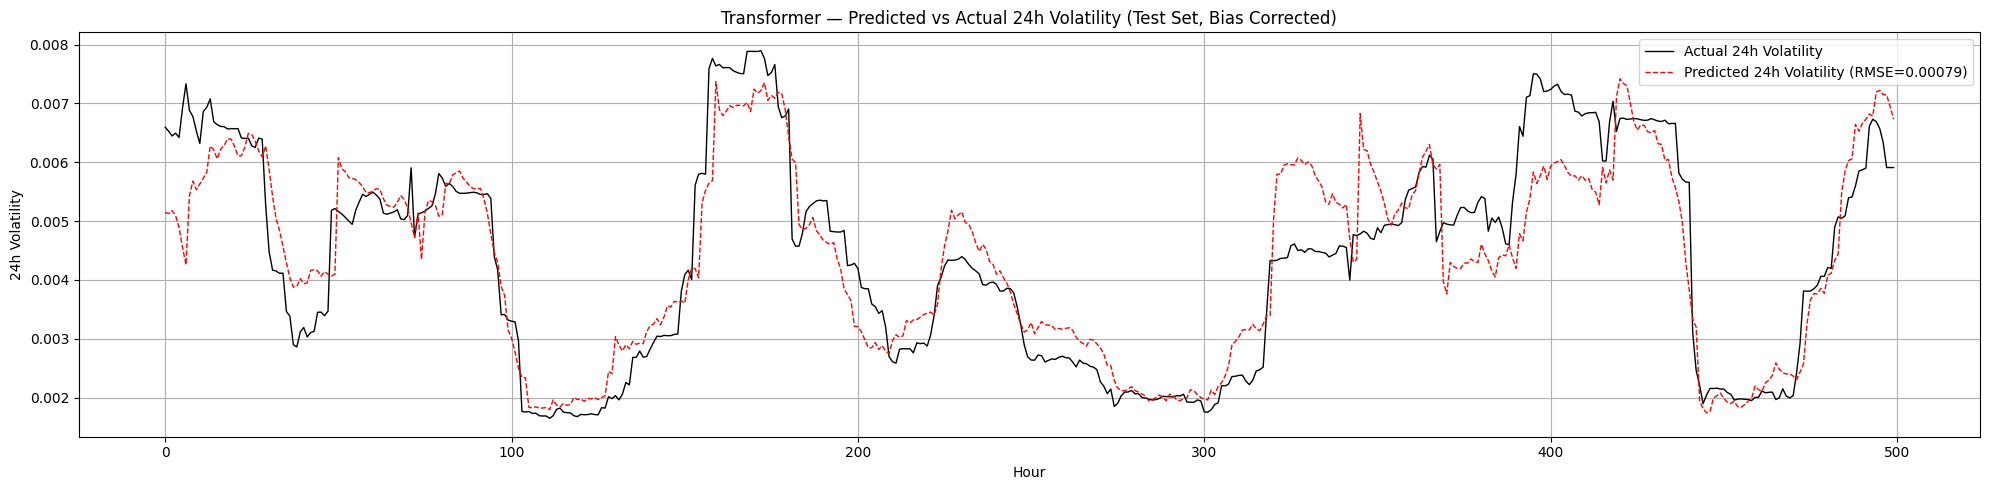

In [ ]:
bias = y_true_log.mean() - y_pred_log.mean()
y_pred_corrected = np.exp(y_pred_log + bias)
y_true_actual = np.exp(y_true_log)

mae_c  = mean_absolute_error(y_true_actual, y_pred_corrected)
rmse_c = np.sqrt(mean_squared_error(y_true_actual, y_pred_corrected))
print(f'MAE (bias corrected):  {mae_c:.6f}')
print(f'RMSE (bias corrected): {rmse_c:.6f}')

plt.figure(figsize=(20, 5))
plt.plot(y_true_actual[:500], label='Actual 24h Volatility', color='black', lw=1)
plt.plot(y_pred_corrected[:500], label=f'Predicted 24h Volatility (RMSE={rmse_c:.5f})', color='red', linestyle='--', lw=1)
plt.title('Transformer — Predicted vs Actual 24h Volatility (Test Set, Bias Corrected)')
plt.xlabel('Hour')
plt.ylabel('24h Volatility')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

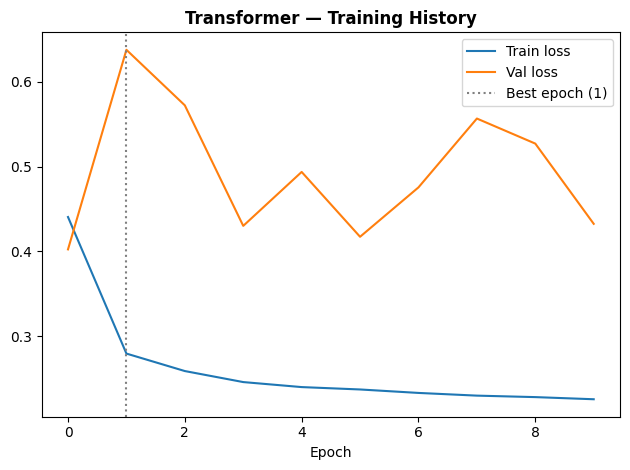

In [ ]:
plt.plot(history_t_b.history['loss'],     label='Train loss')
plt.plot(history_t_b.history['val_loss'], label='Val loss')
best_epoch_t_b = np.argmin(history_t_b.history['val_loss']) + 1
plt.axvline(x=best_epoch_t_b, color='grey', linestyle=':', label=f'Best epoch ({best_epoch_t_b})')
plt.xlabel('Epoch')
plt.legend()
plt.title('Transformer — Training History', fontweight='bold')
plt.tight_layout()
plt.show()

Benchmarking with a TFT

In [ ]:
!pip install neuralforecast ray

In [ ]:
from neuralforecast import NeuralForecast
from neuralforecast.models import TFT

1. Log Returns

In [ ]:
tft_df = A_model.copy().reset_index()  # brings Open time back as column
tft_df = tft_df.rename(columns={'Open time': 'ds', 'target': 'y'})
tft_df['unique_id'] = 'BTC'

n = len(tft_df)
train_end = int(n * 0.7)
val_end   = int(n * 0.85)

tft_train = tft_df.iloc[:train_end]
tft_val   = tft_df.iloc[train_end:val_end]
tft_test  = tft_df.iloc[val_end:]

In [ ]:
from neuralforecast.losses.pytorch import MAE

model_tft = TFT(
    h=1,                    # 1-step ahead forecast
    input_size=48,          # same as the WINDOW
    hidden_size=64,         # keep small — one series
    n_head=4,
    loss=MAE(),
    max_steps=500,
    val_check_steps=50,
    early_stop_patience_steps=5,
    scaler_type='standard',
    hist_exog_list=feature_cols,  # the 15 features as historical covariates
    random_seed=0,
)

nf = NeuralForecast(models=[model_tft], freq='h')

INFO:lightning_fabric.utilities.seed:Seed set to 0


In [ ]:
nf.fit(df=tft_df.iloc[:val_end], val_size=len(tft_val))  # train+val, TFT handles val split internally

INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO:pytorch_lightning.callbacks.model_summary:
  | Name                    | Type                     | Params | Mode 
-----------------------------------------------------------------------------
0 | loss                    | MAE                      | 0      | train
1 | padder_train            | ConstantPad1d            | 0      | train
2 | scaler                  | TemporalNorm             | 0      | train
3 | embedding               | TFTEmbedding             | 2.2 K  | train
4 | temporal_encoder        | TemporalCovariateEncoder | 488 K  | train
5 | temporal_fusion_decoder | TemporalFusionDecoder    | 64.8 K | train
6 | output_adapter          | Linear                   | 65     | train
-------------------------------------------------

Sanity Checking: |          | 0/? [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/pytorch_lightning/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.


Training: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

...

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

INFO:pytorch_lightning.utilities.rank_zero:`Trainer.fit` stopped: `max_steps=500` reached.


In [ ]:

# Predict — neuralforecast predicts the next h steps after the training data
Y_hat = nf.predict()
# Y_hat has columns: unique_id, ds, TFT (or AutoTFT)

# To evaluate on test set properly, use cross_validation
fcst_df = nf.cross_validation(
    df=tft_df,
    val_size=len(tft_val),
    test_size=len(tft_test),
    n_windows=None,
    step_size=1
)

y_pred_tft = fcst_df['TFT'].values  # or 'AutoTFT'
y_true_tft = fcst_df['y'].values

mae_tft  = mean_absolute_error(y_true_tft, y_pred_tft)
rmse_tft = np.sqrt(mean_squared_error(y_true_tft, y_pred_tft))
dir_acc_tft = np.mean(np.sign(y_pred_tft) == np.sign(y_true_tft))

print(f'MAE:             {mae_tft:.6f}')
print(f'RMSE:            {rmse_tft:.6f}')
print(f'Directional Acc: {dir_acc_tft:.2%}')

INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
/usr/local/lib/python3.12/dist-packages/pytorch_lightning/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.


Predicting: |          | 0/? [00:00<?, ?it/s]

INFO:pytorch_lightning.utilities.rank_zero:Trainer already configured with model summary callbacks: [<class 'pytorch_lightning.callbacks.model_summary.ModelSummary'>]. Skipping setting a default `ModelSummary` callback.
INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO:pytorch_lightning.callbacks.model_summary:
  | Name                    | Type                     | Params | Mode 
-----------------------------------------------------------------------------
0 | loss                    | MAE                      | 0      | train
1 | padder_train            | ConstantPad1d            | 0      | train
2 | scaler                  | TemporalNorm             | 0      | train
3 | embedding               | TFTEmbedding             | 2.2 K  | train
4 | temporal_encoder        | TemporalCovaria

Sanity Checking: |          | 0/? [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/pytorch_lightning/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.


Training: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Predicting: |          | 0/? [00:00<?, ?it/s]

MAE:             0.003216
RMSE:            0.004983
Directional Acc: 51.42%


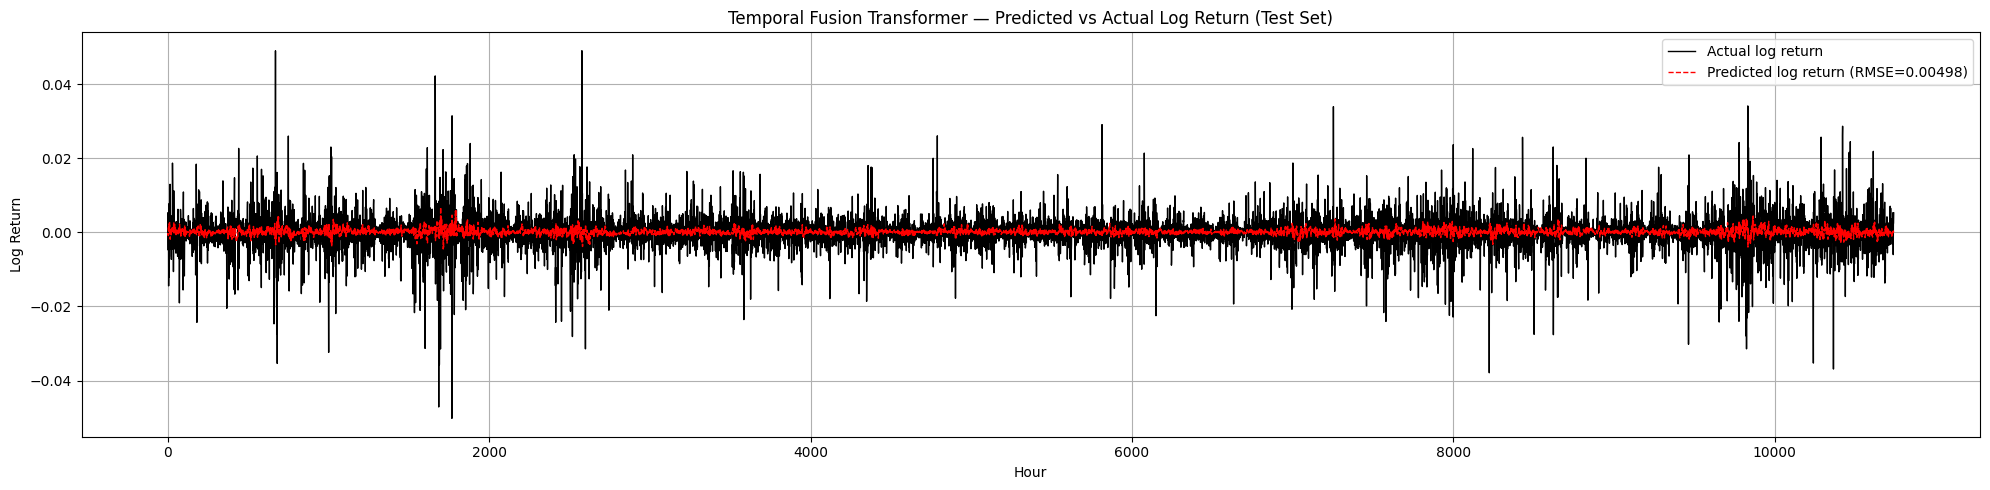

In [ ]:
plt.figure(figsize=(20, 5))
plt.plot(y_true_tft, label='Actual log return', color='black', lw=1)
plt.plot(y_pred_tft, label=f'Predicted log return (RMSE={rmse_tft:.5f})', color='red', linestyle='--', lw=1)
plt.title('Temporal Fusion Transformer — Predicted vs Actual Log Return (Test Set)')
plt.xlabel('Hour')
plt.ylabel('Log Return')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

2. 24h Volatility, but with hyperparameter tuning

In [ ]:
tft_df_b = B_model.copy().reset_index()  # brings Open time back as column
tft_df_b = tft_df_b.rename(columns={'Open time': 'ds', 'target': 'y'})
tft_df_b['unique_id'] = 'BTC'

# Temporal split — same proportions as before
n_b = len(tft_df_b)
train_end_b = int(n_b * 0.7)
val_end_b   = int(n_b * 0.85)

tft_train_b = tft_df_b.iloc[:train_end_b]
tft_val_b   = tft_df_b.iloc[train_end_b:val_end_b]
tft_test_b  = tft_df_b.iloc[val_end_b:]

In [ ]:
from neuralforecast.auto import AutoTFT
from ray import tune

config = {
    "input_size": tune.choice([48]),
    "hidden_size": tune.choice([32, 64]),
    "n_head": tune.choice([2, 4]),
    "learning_rate": tune.loguniform(1e-4, 1e-2),
    "scaler_type": tune.choice(['standard', 'robust']),
    "max_steps": tune.choice([500, 1000]),
    "windows_batch_size": tune.choice([24, 48]),
    "random_seed": tune.randint(1, 10),
}

model_tft_b = AutoTFT(
    h=1,
    loss=MAE(),
    config=config,
    num_samples=10,  # number of configs to try — more is better, min 15 recommended
)

nf_b = NeuralForecast(models=[model_tft_b], freq='h')
nf_b.fit(df=tft_df_b.iloc[:val_end_b],val_size=len(tft_val_b))

2026-05-09 14:53:26,135	INFO worker.py:2012 -- Started a local Ray instance.
/usr/local/lib/python3.12/dist-packages/ray/_private/worker.py:2051: FutureWarning: Tip: In future versions of Ray, Ray will no longer override accelerator visible devices env var if num_gpus=0 or num_gpus=None (default). To enable this behavior and turn off this error message, set RAY_ACCEL_ENV_VAR_OVERRIDE_ON_ZERO=0
  warnings.warn(
2026-05-09 14:53:37,708	INFO tune.py:253 -- Initializing Ray automatically. For cluster usage or custom Ray initialization, call `ray.init(...)` before `Tuner(...)`.


+--------------------------------------------------------------------+
| Configuration for experiment     _train_tune_2026-05-09_14-53-09   |
+--------------------------------------------------------------------+
| Search algorithm                 BasicVariantGenerator             |
| Scheduler                        FIFOScheduler                     |
| Number of trials                 10                                |
+--------------------------------------------------------------------+

View detailed results here: /root/ray_results/_train_tune_2026-05-09_14-53-09
To visualize your results with TensorBoard, run: `tensorboard --logdir /tmp/ray/session_2026-05-09_14-53-09_633730_800/artifacts/2026-05-09_14-53-37/_train_tune_2026-05-09_14-53-09/driver_artifacts`


(_train_tune pid=10007) /usr/local/lib/python3.12/dist-packages/ray/tune/integration/pytorch_lightning.py:198: `ray.tune.integration.pytorch_lightning.TuneReportCallback` is deprecated. Use `ray.tune.integration.pytorch_lightning.TuneReportCheckpointCallback` instead.
(_train_tune pid=10007) Seed set to 9
(_train_tune pid=10007) GPU available: True (cuda), used: True
(_train_tune pid=10007) TPU available: False, using: 0 TPU cores
(_train_tune pid=10007) LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
(_train_tune pid=10007) 
(_train_tune pid=10007)   | Name                    | Type                     | Params | Mode 
(_train_tune pid=10007) -----------------------------------------------------------------------------
(_train_tune pid=10007) 0 | loss                    | MAE                      | 0      | train
(_train_tune pid=10007) 1 | padder_train            | ConstantPad1d            | 0      | train
(_train_tune pid=10007) 2 | scaler                  | TemporalNorm             | 0  

Sanity Checking: |          | 0/? [00:00<?, ?it/s]
Sanity Checking DataLoader 0:   0%|          | 0/1 [00:00<?, ?it/s]


(_train_tune pid=10007) /usr/local/lib/python3.12/dist-packages/pytorch_lightning/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.


...

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

INFO:pytorch_lightning.utilities.rank_zero:`Trainer.fit` stopped: `max_steps=1000` reached.


In [ ]:
fcst_df_b = nf_b.cross_validation(
    df=tft_df_b,
    val_size=len(tft_val_b),
    test_size=len(tft_test_b),
    n_windows=None,
    step_size=1
)

y_pred_tft_b = np.exp(fcst_df_b['AutoTFT'].values)
y_true_tft_b = np.exp(fcst_df_b['y'].values)

mae_tft_b  = mean_absolute_error(y_true_tft_b, y_pred_tft_b)
rmse_tft_b = np.sqrt(mean_squared_error(y_true_tft_b, y_pred_tft_b))
print(f'MAE:  {mae_tft_b:.6f}')
print(f'RMSE: {rmse_tft_b:.6f}')

+--------------------------------------------------------------------+
| Configuration for experiment     _train_tune_2026-05-09_15-01-34   |
+--------------------------------------------------------------------+
| Search algorithm                 BasicVariantGenerator             |
| Scheduler                        FIFOScheduler                     |
| Number of trials                 10                                |
+--------------------------------------------------------------------+

View detailed results here: /root/ray_results/_train_tune_2026-05-09_15-01-34
To visualize your results with TensorBoard, run: `tensorboard --logdir /tmp/ray/session_2026-05-09_14-53-09_633730_800/artifacts/2026-05-09_15-01-34/_train_tune_2026-05-09_15-01-34/driver_artifacts`


(_train_tune pid=12589) /usr/local/lib/python3.12/dist-packages/ray/tune/integration/pytorch_lightning.py:198: `ray.tune.integration.pytorch_lightning.TuneReportCallback` is deprecated. Use `ray.tune.integration.pytorch_lightning.TuneReportCheckpointCallback` instead.
(_train_tune pid=12589) Seed set to 9
(_train_tune pid=12589) GPU available: True (cuda), used: True
(_train_tune pid=12589) TPU available: False, using: 0 TPU cores
(_train_tune pid=12589) LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
(_train_tune pid=12589) 
(_train_tune pid=12589)   | Name                    | Type                     | Params | Mode 
(_train_tune pid=12589) -----------------------------------------------------------------------------
(_train_tune pid=12589) 0 | loss                    | MAE                      | 0      | train
(_train_tune pid=12589) 1 | padder_train            | ConstantPad1d            | 0      | train
(_train_tune pid=12589) 2 | scaler                  | TemporalNorm             | 0  

Epoch 99: 100%|██████████| 1/1 [00:00<00:00, 19.71it/s, v_num=0, train_loss_step=0.217, train_loss_epoch=0.250]
Validation: |          | 0/? [00:00<?, ?it/s]
Validation: |          | 0/? [00:00<?, ?it/s]
Validation DataLoader 0:   0%|          | 0/1 [00:00<?, ?it/s]
(_train_tune pid=12589) 
Epoch 199: 100%|██████████| 1/1 [00:00<00:00, 16.92it/s, v_num=0, train_loss_step=0.151, train_loss_epoch=0.274, valid_loss=0.0499]
Validation: |          | 0/? [00:00<?, ?it/s]
Validation: |          | 0/? [00:00<?, ?it/s]
Validation DataLoader 0:   0%|          | 0/1 [00:00<?, ?it/s]
(_train_tune pid=12589) 
Epoch 299: 100%|██████████| 1/1 [00:00<00:00, 31.81it/s, v_num=0, train_loss_step=0.226, train_loss_epoch=0.189, valid_loss=0.0438]
Validation: |          | 0/? [00:00<?, ?it/s]
Validation: |          | 0/? [00:00<?, ?it/s]
Validation DataLoader 0:   0%|          | 0/1 [00:00<?, ?it/s]
(_train_tune pid=12589) 
Epoch 399: 100%|██████████| 1/1 [00:00<00:00, 42.35it/s, v_num=0, train_loss_step=0.

(_train_tune pid=12589) `Trainer.fit` stopped: `max_steps=500` reached.


(_train_tune pid=12589) 
Epoch 499: 100%|██████████| 1/1 [00:00<00:00,  3.95it/s, v_num=0, train_loss_step=0.157, train_loss_epoch=0.157, valid_loss=0.0407]


...

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

INFO:pytorch_lightning.utilities.rank_zero:`Trainer.fit` stopped: `max_steps=1000` reached.
INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Predicting: |          | 0/? [00:00<?, ?it/s]

MAE:  0.000156
RMSE: 0.000363


In [ ]:
best_config = nf_b.models[0].results.get_best_result().config
for k, v in best_config.items():
    print(f'{k}: {v}')

input_size: 48
hidden_size: 32
n_head: 4
learning_rate: 0.0035757424365194294
scaler_type: standard
max_steps: 1000
windows_batch_size: 48
random_seed: 9
h: 1
loss: MAE()
valid_loss: MAE()


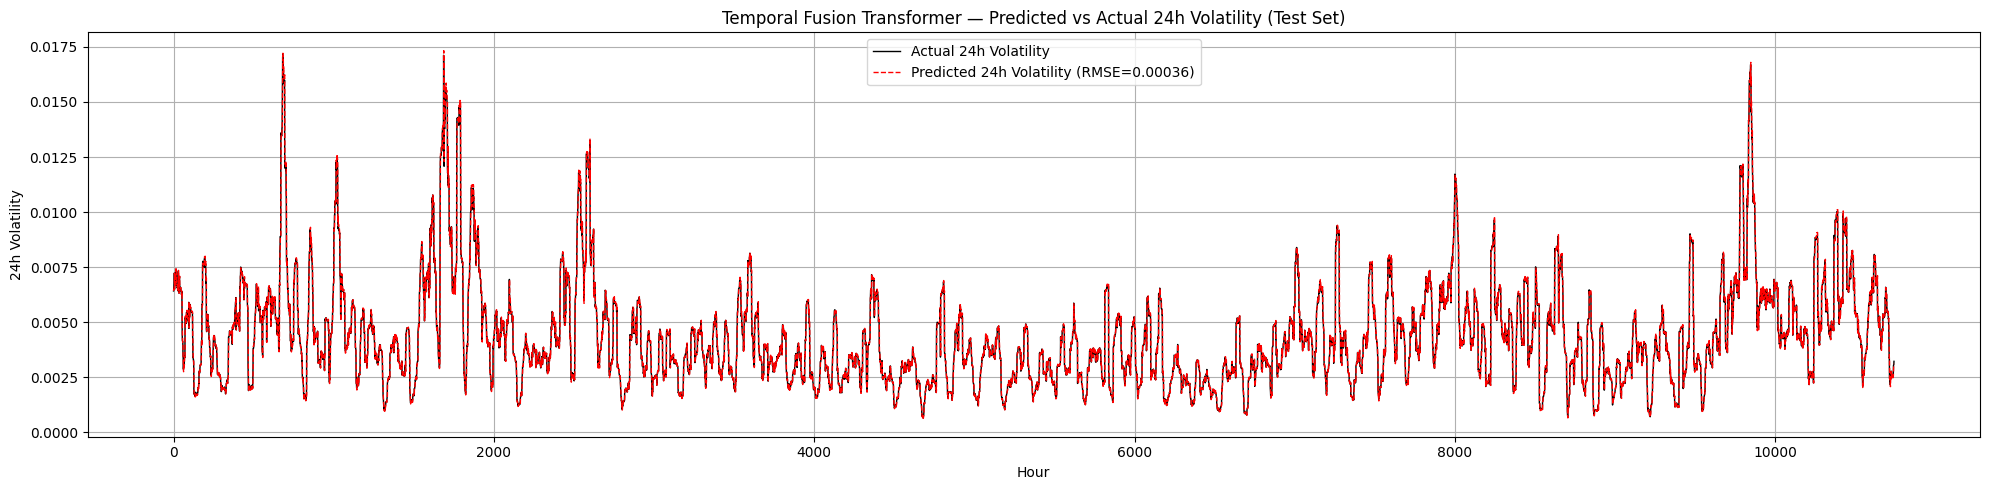

In [ ]:
plt.figure(figsize=(20, 5))
plt.plot(y_true_tft_b, label='Actual 24h Volatility', color='black', lw=1)
plt.plot(y_pred_tft_b, label=f'Predicted 24h Volatility (RMSE={rmse_tft_b:.5f})', color='red', linestyle='--', lw=1)
plt.title('Temporal Fusion Transformer — Predicted vs Actual 24h Volatility (Test Set)')
plt.xlabel('Hour')
plt.ylabel('24h Volatility')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()